# Housing Data Analysis

## Setup

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## Data Loading and Preprocessing

In [2]:
from cleaning_preprocessing import preproccesing

df = pd.read_csv('ames_housing.csv')
ames, column_breakdown = preproccesing(df)

In [3]:
# Note that I have noticed that BsmtFin_Type_2 was not included in the ordinal map from Mat's code I adjust it here

bsmt_fin_type_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
ames['BsmtFin_Type_2'] = ames['BsmtFin_Type_2'].fillna('None').map(bsmt_fin_type_map)


In [4]:
categorical_vars = [col for fam in column_breakdown.values() for col in fam.get('categorical', [])]
numerical_vars = [col for fam in column_breakdown.values() for col in fam.get('numerical', [])]
ordinal_vars = [col for fam in column_breakdown.values() for col in fam.get('ordinal', [])]
all_feature_vars = categorical_vars + numerical_vars + ordinal_vars

In [5]:
mask = ames[all_feature_vars].notna().all(axis=1)
ames = ames[mask].reset_index(drop=True)

In [6]:
y_cont = ames['SalePrice']  # continuous (regression target)
y_cat  = (ames['HighSalePrice'] == 'High').astype(int)  # 1 = above median

In [7]:
print(f"Observations : {len(ames):,}")
print(f"Features total : {len(all_feature_vars)}")
print(f"  Categorical : {len(categorical_vars)}")
print(f"  Numerical : {len(numerical_vars)}")
print(f"  Ordinal : {len(ordinal_vars)}")
print(f"High-price homes (above median SalePrice): {y_cat.mean():.1%}")

Observations : 2,927
Features total : 79
  Categorical : 23
  Numerical : 36
  Ordinal : 20
High-price homes (above median SalePrice): 49.9%


## PCA Analysis

The Ames dataset contains 56 numerical and ordinal features that are strongly correlated. As we have seen larger homes tend to have larger garages, more bathrooms and higher quaality ratings. It therefore makes sense to investigate the dataset with PCA as we hope that PCA will dins a small set of orthogonal directions that capture most of this shared variation. This will allow us to

1. Quantify how many independent axes of variation exists among housing features. 
2. Identify what each axis represents by examining the feature loadings. 
3. Visualize whether price categories separate along those axes.


To do PCA, we will use only the numerical variables and the ordinal variables. Below is the analysis: (Did we include in the preprocessing analysis that we excluded sales price and high  sales price? rememeber to check!)

In [8]:
pca_features = numerical_vars + ordinal_vars  # 56 features

X_pca_input = ames[pca_features].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cumvar = np.cumsum(evr)

n_80 = int(np.argmax(cumvar >= 0.80)) + 1
n_90 = int(np.argmax(cumvar >= 0.90)) + 1

In [9]:
print(f"PCA input shape : {X_scaled.shape}")
print(f"PC1 explains : {evr[0]:.1%} of variance")
print(f"PC1+PC2 : {cumvar[1]:.1%}")
print(f"PC1–PC5 : {cumvar[4]:.1%}")
print(f"PCs for 80% var : {n_80}")
print(f"PCs for 90% var : {n_90}")

PCA input shape : (2927, 56)
PC1 explains : 18.7% of variance
PC1+PC2 : 25.8%
PC1–PC5 : 40.5%
PCs for 80% var : 24
PCs for 90% var : 32


Here we visualize the results:

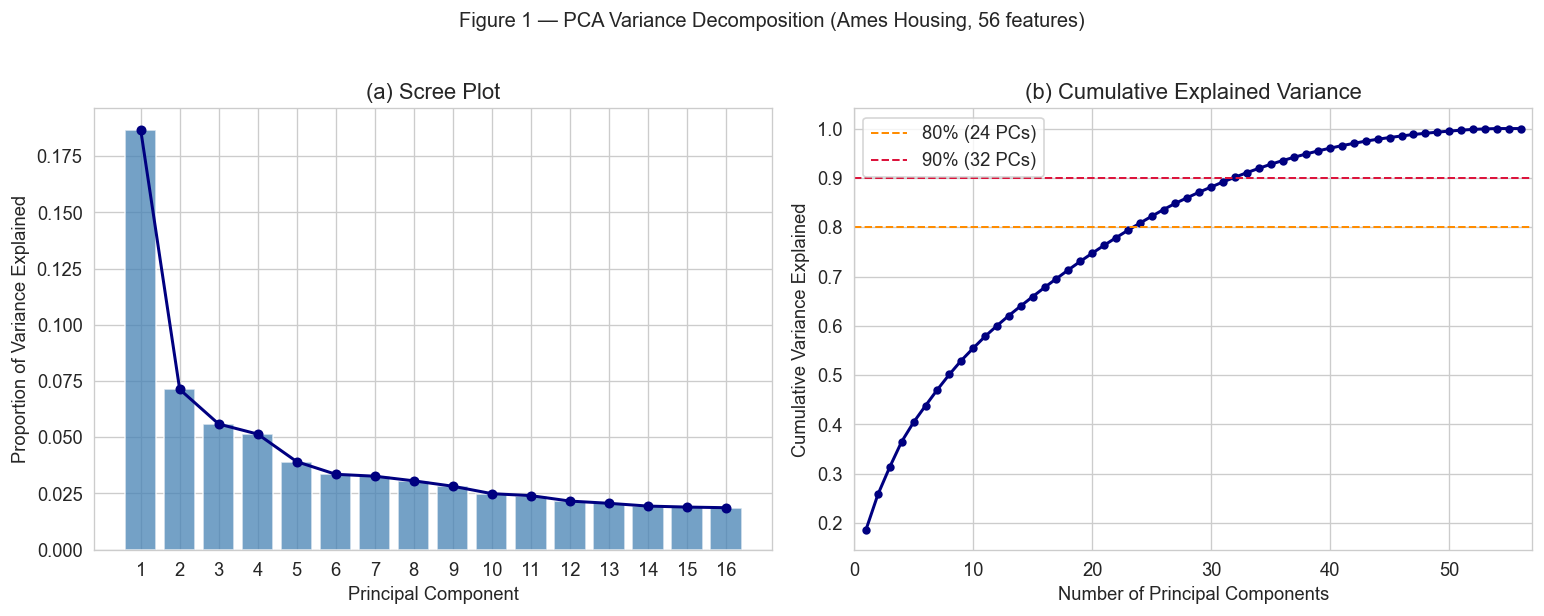

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree
axes[0].bar(range(1, 17), evr[:16], alpha=0.75, color='steelblue')
axes[0].plot(range(1, 17), evr[:16], 'o-', color='navy', linewidth=1.8, markersize=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('(a) Scree Plot')
axes[0].set_xticks(range(1, 17))

# Cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='navy',
             linewidth=1.8, markersize=4)
axes[1].axhline(0.80, color='darkorange', linestyle='--', linewidth=1.2,
                label=f'80% ({n_80} PCs)')
axes[1].axhline(0.90, color='crimson', linestyle='--', linewidth=1.2,
                label=f'90% ({n_90} PCs)')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('(b) Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xlim(0, len(cumvar) + 1)

plt.suptitle('Figure 1 — PCA Variance Decomposition (Ames Housing, 56 features)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig1_pca_variance.pdf', bbox_inches='tight')
plt.show()

The scree plot doesn't have a clear elbow structure. PC1 oly explains 18.7% of total variance. As we have seen in class, datasets with strong latent structure often have PC1 explaining about 40-60% of total variance. This revales that the Ames hsoing data has many weak orthogonal dimensions rather than few strong ones. Howing characteristics don't reduce to a single, or a few, underlying dimensions. Furthermore note from graph b that we need 24 PCs to capture 80% of total variance, this is a 57% reduction from 56 features which is modest. As we have seen a true "compressible" dataset would hit 80% with 5 to 10 components and the gradually descending scree confirms this. Long story short, the data seems to have structure but it is distributed across many dimensions rather than a concentrated few.  

Here we show further investigation on the OCA loadings and their interpretability.

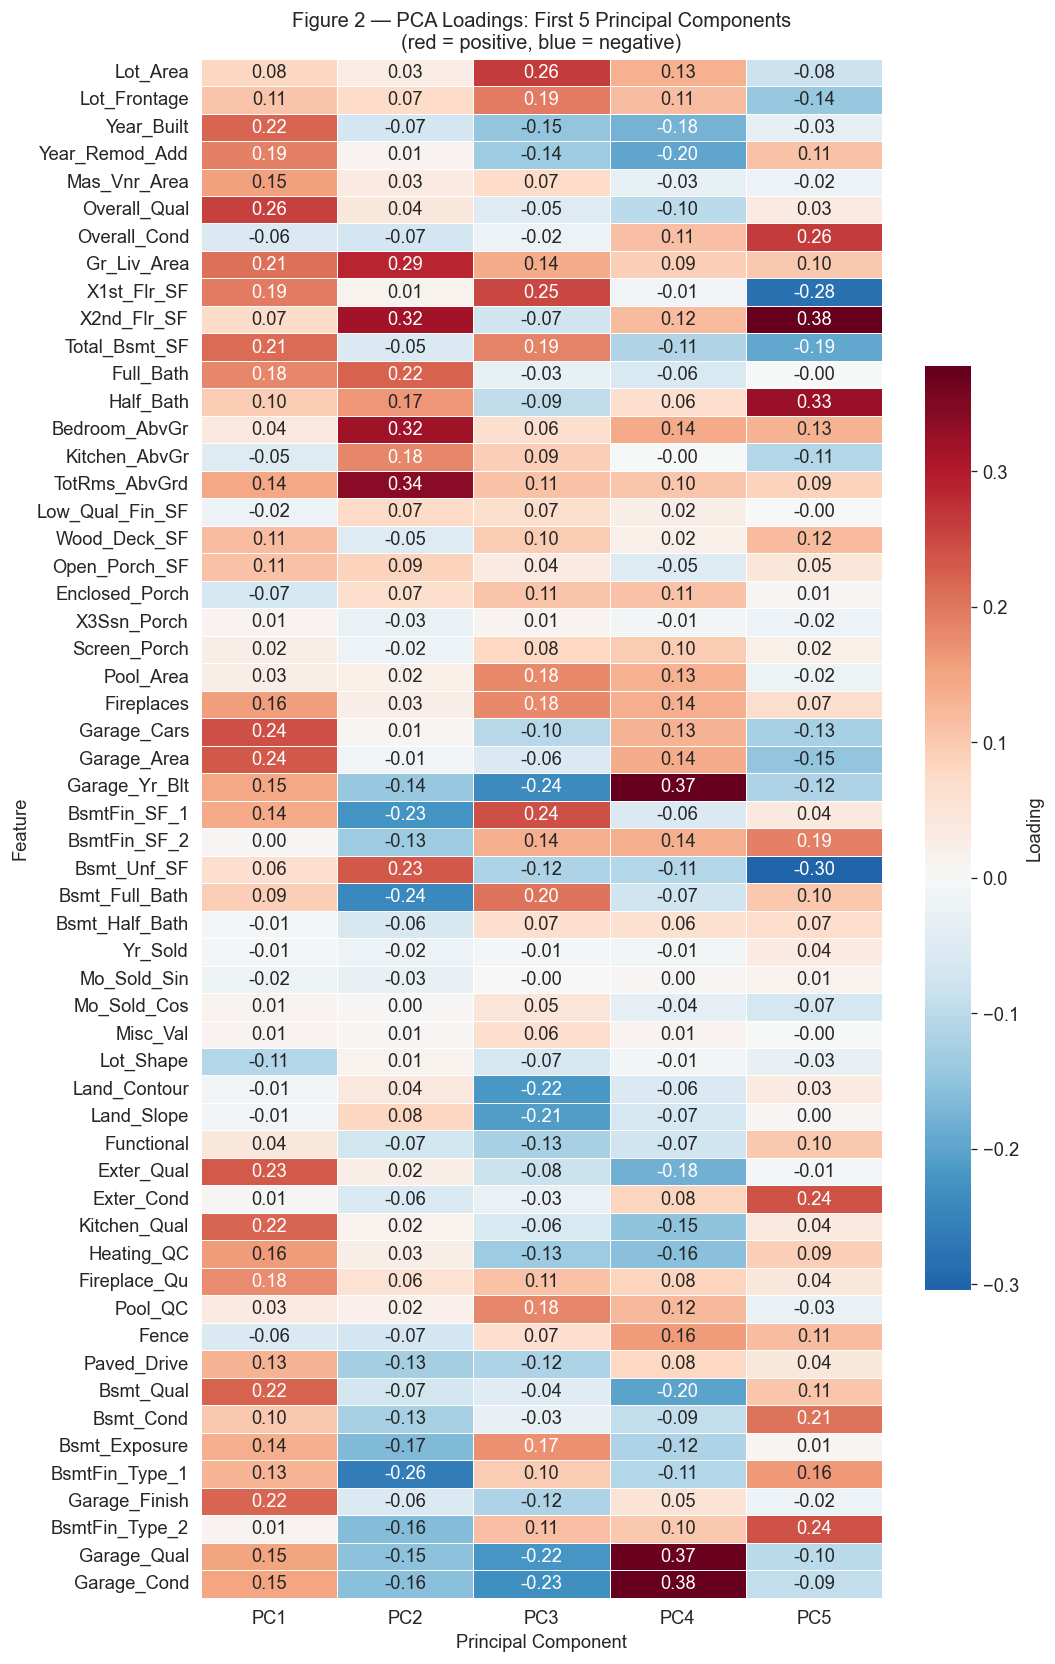

In [11]:
#Figure 2: Loadings heatmap for PC1–PC5
n_pcs_show = 5
loadings = pd.DataFrame(
    pca.components_[:n_pcs_show].T,
    index=pca_features,
    columns=[f'PC{i+1}' for i in range(n_pcs_show)]
)

plt.figure(figsize=(9, 14))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)
plt.title('Figure 2 — PCA Loadings: First 5 Principal Components\n'
          '(red = positive, blue = negative)', fontsize=12)
plt.xlabel('Principal Component')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('Analysis_Figs/fig2_pca_loadings.pdf', bbox_inches='tight')
plt.show()

In [12]:
# Top contributors to each of the first 5 PCs
for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    top_pos = loadings[pc].nlargest(5)
    top_neg = loadings[pc].nsmallest(3)
    print(f'\n=== {pc} ({evr[int(pc[2:])-1]:.1%} variance) ===================')
    print('  Positive (high loading):')
    for feat, val in top_pos.items():
        print(f'    {feat:<25} {val:+.3f}')
    print('  Negative (high magnitude):')
    for feat, val in top_neg.items():
        print(f'    {feat:<25} {val:+.3f}')


=== PC1 (18.7% variance) ===================
  Positive (high loading):
    Overall_Qual              +0.257
    Garage_Cars               +0.243
    Garage_Area               +0.235
    Exter_Qual                +0.229
    Bsmt_Qual                 +0.221
  Negative (high magnitude):
    Lot_Shape                 -0.109
    Enclosed_Porch            -0.066
    Fence                     -0.059

=== PC2 (7.1% variance) ===================
  Positive (high loading):
    TotRms_AbvGrd             +0.340
    Bedroom_AbvGr             +0.319
    X2nd_Flr_SF               +0.316
    Gr_Liv_Area               +0.286
    Bsmt_Unf_SF               +0.232
  Negative (high magnitude):
    BsmtFin_Type_1            -0.264
    Bsmt_Full_Bath            -0.242
    BsmtFin_SF_1              -0.227

=== PC3 (5.6% variance) ===================
  Positive (high loading):
    Lot_Area                  +0.262
    X1st_Flr_SF               +0.250
    BsmtFin_SF_1              +0.244
    Bsmt_Full_Bath    

Inspecting the top loadings on each component will reveal what each axis of variation represents and what it fails to represent cleanly.

**PC1 (18.7% variance) — "General Quality and Garage."** The top loadings combine quality ratings (`Overall_Qual`, `Exter_Qual`, `Bsmt_Qual`) with garage characteristics (`Garage_Cars`, `Garage_Area`). This can be put together as "house desirability" axis, but it conflates two intuitively distinct constructs: how well-built the home is and how much garage it has. Furthermore note how the negative loadings (`Lot_Shape`, `Enclosed_Porch`, `Fence`) are weak (< 0.11 in magnitude) and don't form a coherent counter-construct. Theefore PC1 seems to capture a meaningful but composite dimension.

**PC2 (7.1% variance) — "Vertical Space vs Finished Basement."** This component contrasts above-ground living (`TotRms_AbvGrd`, `Bedroom_AbvGr`, `X2nd_Flr_SF`, `Gr_Liv_Area`) against finished basement features (`BsmtFin_Type_1`, `Bsmt_Full_Bath`, `BsmtFin_SF_1`). This is a mathematical contrast capturing variance left over after PC1: two-story homes with bedrooms upstairs tend to have less finished basement, and vice versa. This makes intutive sense. 

**PC3 (5.6% variance) — "Lot Size and Footprint vs Garage Age."** Here we are mixing lot area, first-floor footprint, and basement finish positively against garage age/quality negatively. We therefore get three quasi-distinct concepts (lot, footprint, garage) bundled into a single mathematical axis by the constraint of orthogonality to PC1 and PC2, this likely is not a true latent dimension of the howing data, but rather a orthogonality construct.

**PC4 (5.1% variance) — "Garage Quality Standalone."** Loads almost exclusively on garage condition variables (`Garage_Cond`, `Garage_Yr_Blt`, `Garage_Qual`) against general quality features (`Bsmt_Qual`, `Year_Remod_Add`, `Exter_Qual`). This is interesting: garage variables already loaded on PC1, but they reappear here in a separate axis because they share variance that PC1 didn't fully capture. PCA is therefore essentially "double-counting" the garage construct across multiple components which is not really what we would want. 

**PC5 (3.9% variance) — "Upper Floor vs Ground/Basement."** Contrasts second-floor square footage and half-baths against first-floor and basement square footage. A geometric distinction between vertical and horizontal home expansion, captured as residual variance after the first four PCs.


### Conclusions on PCA

Three patterns emerge across the first five PCs:

1. **No PC represents a single clean construct.** PC1 mixes Quality with Garage; PC2 contrasts vertical vs basement structure; PC3 mixes lot, footprint, and garage age. The interpretable "constructs" we'd expect in housing data — Quality, Size, Age, Garage, Basement Finish — appear *fragmented across multiple PCs* rather than each living in its own component.

2. **Variance is spread out.** PC1 captures only 18.7%, and PCs 2–5 contribute another 21.7% — meaning 60% of variance still lies in PC6 onwards. Reaching 80% requires 24 PCs (a 57% reduction from 56 features, which is modest). There is no small set of dominant axes.

3. **The same features recur in multiple PCs.** Garage variables load substantially on PC1, PC3, and PC4. Basement features load on PC2, PC3, and PC5. This indicates that PCA is not isolating "the garage construct" or "the basement construct", it's slicing each construct's variance across several orthogonal directions.

## Factor Analysis

### Why Factor Analysis Is the Natural Next Step

The three points above aren't failures of PCA; rather they're symptoms of a mismatch between what PCA optimizes and what we want to discover. PCA maximizes total variance, including the idiosyncratic noise of each feature. When many features have substantial feature-specific variance (which the diffuse scree plot strongly suggests is the case here), PCA spreads that noise across components and dilutes the underlying structure. This produces the fragmentation we see: garage variance gets split across PC1 and PC4 because PCA can't separate "shared garage construct" from "garage-specific noise."

Factor Analysis is designed to address exactly this. Where PCA models $X = \text{Components} \times \text{Scores}$, Factor Analysis models:

$$X = \Lambda F + \epsilon$$

or equivalently


$$X_i = \lambda_{i1} F_1 + \lambda_{i2} F_2 + \cdots + \lambda_{ik} F_k + \varepsilon_i$$

explicitly separating shared variance ($\Lambda F$, captured by latent factors) from unique/idiosyncratic variance ($\epsilon$, captured per-feature in `noise_variance_`). Three concrete advantages for our setting:

- **FA recovers cleaner constructs** by not trying to explain feature-specific noise. The garage variables should converge onto a single "Garage" factor rather than fragmenting across multiple components.
- **FA admits rotation.** Varimax rotation redistributes loadings so each factor represents a distinct, nameable construct rather than a mathematical superposition. PCA components are fixed by the variance-maximization criterion and cannot be rotated without losing the orthogonality property that defines them.
- **FA explicitly quantifies what doesn't fit.** Each feature's communality ($h^2 = 1 - \text{noise\_variance}$) tells us how much of its variance the factor model explains. Features with low $h^2$ are flagged as idiosyncratic rather than silently absorbed into low-variance PCs.

We therefore proceed to Factor Analysis as the methodologically appropriate tool for recovering interpretable latent dimensions from this data, with the expectation that fewer factors will capture more interpretive structure than the 24 PCs needed to reach 80% variance under PCA.

In [13]:
from sklearn.decomposition import FactorAnalysis

### Setting Up FA

Before fitting any model, we need to answer a question PCA glossed over: how many latent factors should we extract? PCA could keep all 56 components by construction; FA requires us to specify `k` upfront. We will combine three approaches to make this decision:

1. **Kaiser criterion** — a classical baseline that retains factors corresponding to eigenvalues greater than 1.
2. **Information criteria (AIC and BIC)** — model-selection metrics that balance model fit (log-likelihood) against complexity (number of free parameters).
3. **Structural inspection of the criterion curves** — looking at where the curves bend rather than only where they reach their numerical minimum.

We start with the Kaiser baseline, then scan a wide range of `k` values to compute AIC and BIC for each.

In [14]:
# Kaiser baseline 
corr_mat = np.corrcoef(X_scaled.T)
eig_corr = np.linalg.eigvalsh(corr_mat)[::-1]
n_kaiser = int((eig_corr > 1).sum())
print(f"Kaiser criterion (λ > 1): {n_kaiser} factors")

Kaiser criterion (λ > 1): 17 factors


Factor analysis has a hard mathematical ceiling on the number of factors that can be identified. With `p` features, the **Ledermann bound** (https://search.r-project.org/CRAN/refmans/IMIFA/html/Ledermann.html) restricts us to:

$$k_{\max} = \left\lfloor \frac{2p + 1 - \sqrt{8p + 1}}{2} \right\rfloor$$

For our 56 features, this gives $k_{\max} = 44$. Beyond that, the model has more parameters than the covariance matrix has unique entries, and the solution is not uniquely identifiable. We scan up to $k_{\max} - 2 = 42$ to stay safely below this ceiling. This is wide enough to cover any realistic number of latent housing constructs while still terminating in reasonable time.

In [15]:
n_samples, n_features = X_scaled.shape
k_ceiling = int((2*n_features + 1 - np.sqrt(8*n_features + 1)) / 2)  # = 44
k_max = min(k_ceiling - 2, 50)
n_range = range(1, k_max + 1)

print(f"Features: {n_features}, theoretical max factors: {k_ceiling}, scanning to k={k_max}")

Features: 56, theoretical max factors: 45, scanning to k=43


For each candidate `k`, we fit a Factor Analysis model and compute three quantities:

- **Log-likelihood** — measures how well the model fits the data.
- **AIC** = $2 \cdot n_\text{params} - 2 \cdot \ell$ — penalizes complexity with a fixed cost of 2 per parameter.
- **BIC** = $n_\text{params} \cdot \log(n) - 2 \cdot \ell$ — penalizes complexity more aggressively as sample size grows; standard for model selection with moderate-to-large `n`.

The parameter count $n_\text{params} = p \cdot k + p - k(k-1)/2$ comes from counting: `p × k` loadings + `p` unique variances, minus `k(k-1)/2` for the rotational indeterminacy of FA (any orthogonal rotation of the loadings is equivalent, so those degrees of freedom shouldn't be counted as free parameters)

We also store **total communality** $\Sigma h^2$ as a complementary fit metric — how much of the total feature variance the factor model explains.

In [16]:
total_communality = []
log_likelihoods = []
aic_scores = []
bic_scores = []

for k in n_range:
    fa_k = FactorAnalysis(n_components=k, random_state=42, max_iter=1000)
    fa_k.fit(X_scaled)

    ll = fa_k.score(X_scaled) * n_samples
    log_likelihoods.append(ll)
    total_communality.append((1 - fa_k.noise_variance_).sum())
    n_params = n_features * k + n_features - k * (k - 1) / 2

    aic_scores.append(2 * n_params - 2 * ll)
    bic_scores.append(n_params * np.log(n_samples) - 2 * ll)

In [17]:
n_factors_aic = list(n_range)[int(np.argmin(aic_scores))]
n_factors_bic = list(n_range)[int(np.argmin(bic_scores))]

print(f"AIC-optimal: {n_factors_aic} factors")
print(f"BIC-optimal: {n_factors_bic} factors")

AIC-optimal: 42 factors
BIC-optimal: 19 factors


The raw numerical minima tell different stories: AIC selects **k = 42** (the boundary of our scan range), while BIC selects **k = 19**. These are not compatible answers, and neither is obviously correct. We will investigate this disagreement carefully before settling on a final value.

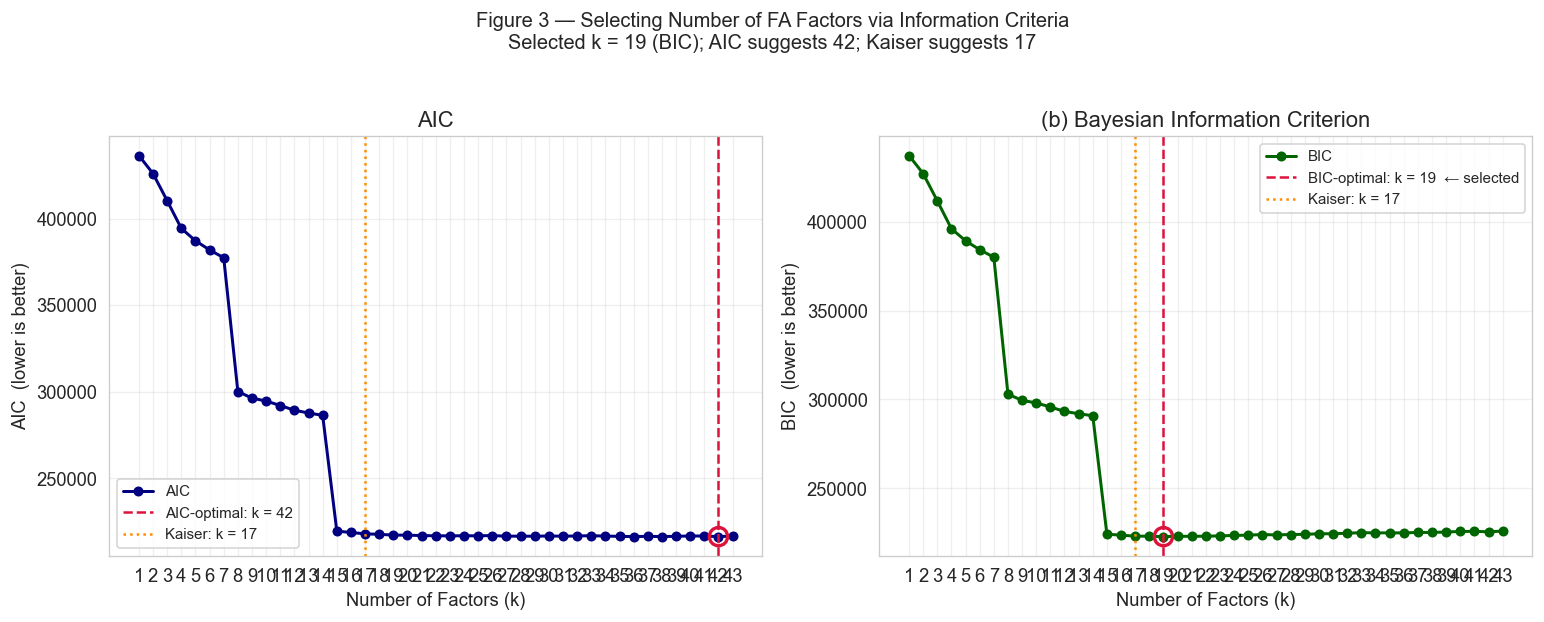

AIC-optimal k = 42   (AIC = 216343.8)
BIC-optimal k = 19   (BIC = 222897.3)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

aic_arr = np.array(aic_scores)
bic_arr = np.array(bic_scores)
ks = np.array(list(n_range))

# (a) AIC curve
axes[0].plot(ks, aic_arr, 'o-', color='navy', linewidth=1.8, markersize=5,
             label='AIC')
axes[0].axvline(n_factors_aic, color='crimson', linestyle='--', linewidth=1.5,
                label=f'AIC-optimal: k = {n_factors_aic}')
axes[0].axvline(n_kaiser, color='darkorange', linestyle=':', linewidth=1.5,
                label=f'Kaiser: k = {n_kaiser}')


axes[0].scatter([n_factors_aic], [aic_arr.min()], s=120, facecolors='none',
                edgecolors='crimson', linewidths=2, zorder=5)
axes[0].set_xlabel('Number of Factors (k)')
axes[0].set_ylabel('AIC  (lower is better)')
axes[0].set_title('AIC')
axes[0].set_xticks(ks)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# (b) BIC curve
axes[1].plot(ks, bic_arr, 'o-', color='darkgreen', linewidth=1.8, markersize=5,
             label='BIC')
axes[1].axvline(n_factors_bic, color='crimson', linestyle='--', linewidth=1.5,
                label=f'BIC-optimal: k = {n_factors_bic}  ← selected')
axes[1].axvline(n_kaiser, color='darkorange', linestyle=':', linewidth=1.5,
                label=f'Kaiser: k = {n_kaiser}')
axes[1].scatter([n_factors_bic], [bic_arr.min()], s=120, facecolors='none',
                edgecolors='crimson', linewidths=2, zorder=5)


near_best = ks[bic_arr - bic_arr.min() < 2]
if len(near_best) > 1:
    axes[1].axvspan(near_best.min() - 0.4, near_best.max() + 0.4,
                    color='gray', alpha=0.12,
                    label=f'ΔBIC < 2 (k ∈ {near_best.min()}–{near_best.max()})')
axes[1].set_xlabel('Number of Factors (k)')
axes[1].set_ylabel('BIC  (lower is better)')
axes[1].set_title('(b) Bayesian Information Criterion')
axes[1].set_xticks(ks)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(
    f'Figure 3 — Selecting Number of FA Factors via Information Criteria\n'
    f'Selected k = {n_factors_bic} (BIC); AIC suggests {n_factors_aic}; Kaiser suggests {n_kaiser}',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig3_fa_selection.pdf', bbox_inches='tight')
plt.show()

# Summary
print(f"AIC-optimal k = {n_factors_aic}   (AIC = {aic_arr.min():.1f})")
print(f"BIC-optimal k = {n_factors_bic}   (BIC = {bic_arr.min():.1f})")
if len(near_best) > 1:
    print(f"Models within ΔBIC < 2 of best: k ∈ {list(near_best)}  "
          f"(statistically comparable)")

#### Interpreting the Information Criteria Curves

The headline numbers — "BIC selects k=19, AIC selects k=42" — are misleading. The **shape** of both curves is far more informative than where they bottom out:

- Both AIC and BIC drop **steeply** from k=1 through k=7, indicating each added factor captures substantial structure.
- There is a sharp **cliff between k=7 and k=8** — the single largest drop in either curve. This is the strongest structural signal in the entire scan.
- After k=15, both curves are **essentially flat** all the way out to the scan boundary.
- BIC's "minimum at k=19" sits inside the gray ΔBIC < 2 band, meaning models from k=15 through k=22 are statistically indistinguishable under the Kass-Raftery rule of thumb (ΔBIC < 2 implies models are not meaningfully different).

This pattern has a specific interpretation. The data has **real structure with about 7 dominant latent dimensions** (producing the steep descent), some weaker secondary structure between k=8 and k=15 (the moderate descent), and beyond that, the criteria are just rewarding the model for absorbing each feature's idiosyncratic variance into its own dedicated factor.

We therefore have four candidate solutions to consider:

| k | Source | Interpretation |
|---|---|---|
| **7** | The cliff in AIC/BIC | The strongest structural signal — likely the true latent dimensionality |
| **15** | Secondary plateau | Adds some real secondary structure but also doublets and singletons |
| **19** | BIC numerical minimum | Inside ΔBIC < 2 of k=15; a wiggle in a flat basin, not a meaningful peak |
| **42** | AIC numerical minimum | At the scan boundary, near the identifiability ceiling — fitting noise |

**k=42 is ruled out immediately.** It sits adjacent to the Ledermann ceiling of 44, where the model is severely over-parameterized. AIC's complexity penalty (a flat 2 per parameter) is too lenient for FA at this scale, and "factors" at that level become single-feature noise sinks. AIC's recommendation here is a known weakness of the criterion, not a real finding.

**k=19 is ruled out by the ΔBIC < 2 band.** Picking the exact numerical minimum from a flat basin is overfitting to noise in the criterion itself. The honest reading of BIC is "anywhere from k=15 to k=22 fits equally well" — we have no statistical basis for preferring k=19 over its neighbors.

This leaves **k=7 (the cliff) and k=15 (the secondary plateau)** as the meaningful candidates. We will fit both and use the k=15 solution as a robustness check on the simpler k=7 solution.

#### The Need for Rotation

We first fit FA at k=7 without rotation. Unrotated factor analysis has a well-known limitation: the first factor tends to act as a **"g-factor"** that loads on nearly every variable, with subsequent factors capturing residual contrasts. This is a mathematical artifact of how FA maximizes likelihood — it greedily packs the most variance into F1, leaving smaller, harder-to-interpret patterns for later factors.

To recover interpretable, named constructs (Quality, Garage, Size, etc.) we need to rotate the loadings. **Varimax rotation** is the standard choice: it preserves the total communality (rotation is volume-preserving) but redistributes loadings so each variable loads strongly on one factor and weakly on others. This is what factor analysts call achieving **"simple structure."**

In [19]:
# Unrotated k=7
fa7 = FactorAnalysis(n_components=7, random_state=42, max_iter=1000)
fa7.fit(X_scaled)
load7_unrot = pd.DataFrame(
    fa7.components_.T,
    index=pca_features,
    columns=[f'F{i+1}' for i in range(7)]
)

We now fit the same 7-factor model with Varimax rotation. The factor solution has the same total fit as the unrotated version, but the loading pattern should be dramatically more interpretable.

In [20]:
# Varimax-rotated k=7 (primary solution)
fa7_rot = FactorAnalysis(n_components=7, rotation='varimax',
                          random_state=42, max_iter=1000)
fa7_rot.fit(X_scaled)

load7_rot = pd.DataFrame(
    fa7_rot.components_.T,
    index=pca_features,
    columns=[f'F{i+1}' for i in range(7)]
)
comm7_rot = pd.Series(1 - fa7_rot.noise_variance_, index=pca_features)

print(f"Total communality (k=7, Varimax) : {comm7_rot.sum():.2f} / {len(pca_features)}")
print(f"Mean communality                  : {comm7_rot.mean():.3f}")
print(f"h² > 0.5                          : {(comm7_rot > 0.5).sum()} features")
print(f"h² < 0.2                          : {(comm7_rot < 0.2).sum()} features")

Total communality (k=7, Varimax) : 23.11 / 56
Mean communality                  : 0.413
h² > 0.5                          : 23 features
h² < 0.2                          : 22 features


#### Fitting k=15

We also fit the k=15 Varimax solution. This is our robustness check: if k=15 produces a small number of additional, nameable factors (say, an "Outdoor Amenities" factor or a "Condition" factor), that would suggest k=7 is missing real structure. If instead k=15 produces mostly single-feature factors and arbitrary splits, it confirms that k=7 captures the true latent dimensionality and the extra factors at k=15 are just absorbing noise.

In [21]:
# Varimax-rotated k=15 
fa15_rot = FactorAnalysis(n_components=15, rotation='varimax',
                           random_state=42, max_iter=1000)
fa15_rot.fit(X_scaled)

load15_rot = pd.DataFrame(
    fa15_rot.components_.T,
    index=pca_features,
    columns=[f'F{i+1}' for i in range(15)]
)
comm15_rot = pd.Series(1 - fa15_rot.noise_variance_, index=pca_features)

print(f"Total communality (k=15, Varimax) : {comm15_rot.sum():.2f} / {len(pca_features)}")

Total communality (k=15, Varimax) : 31.56 / 56


#### Solutions

To make the factor structure visible, we sort features by their **primary factor** (the factor on which they load most strongly). After sorting, the loadings heatmap shows a clear block-diagonal pattern: each factor's features cluster together visually.

In [22]:
def sort_by_primary(loadings):
    primary = loadings.abs().idxmax(axis=1)
    strength = loadings.abs().max(axis=1)
    order = (pd.DataFrame({'factor': primary, 'loading': strength})
             .sort_values(['factor', 'loading'], ascending=[True, False])
             .index)
    return order, primary

order_7,  primary_7  = sort_by_primary(load7_rot)
order_15, primary_15 = sort_by_primary(load15_rot)

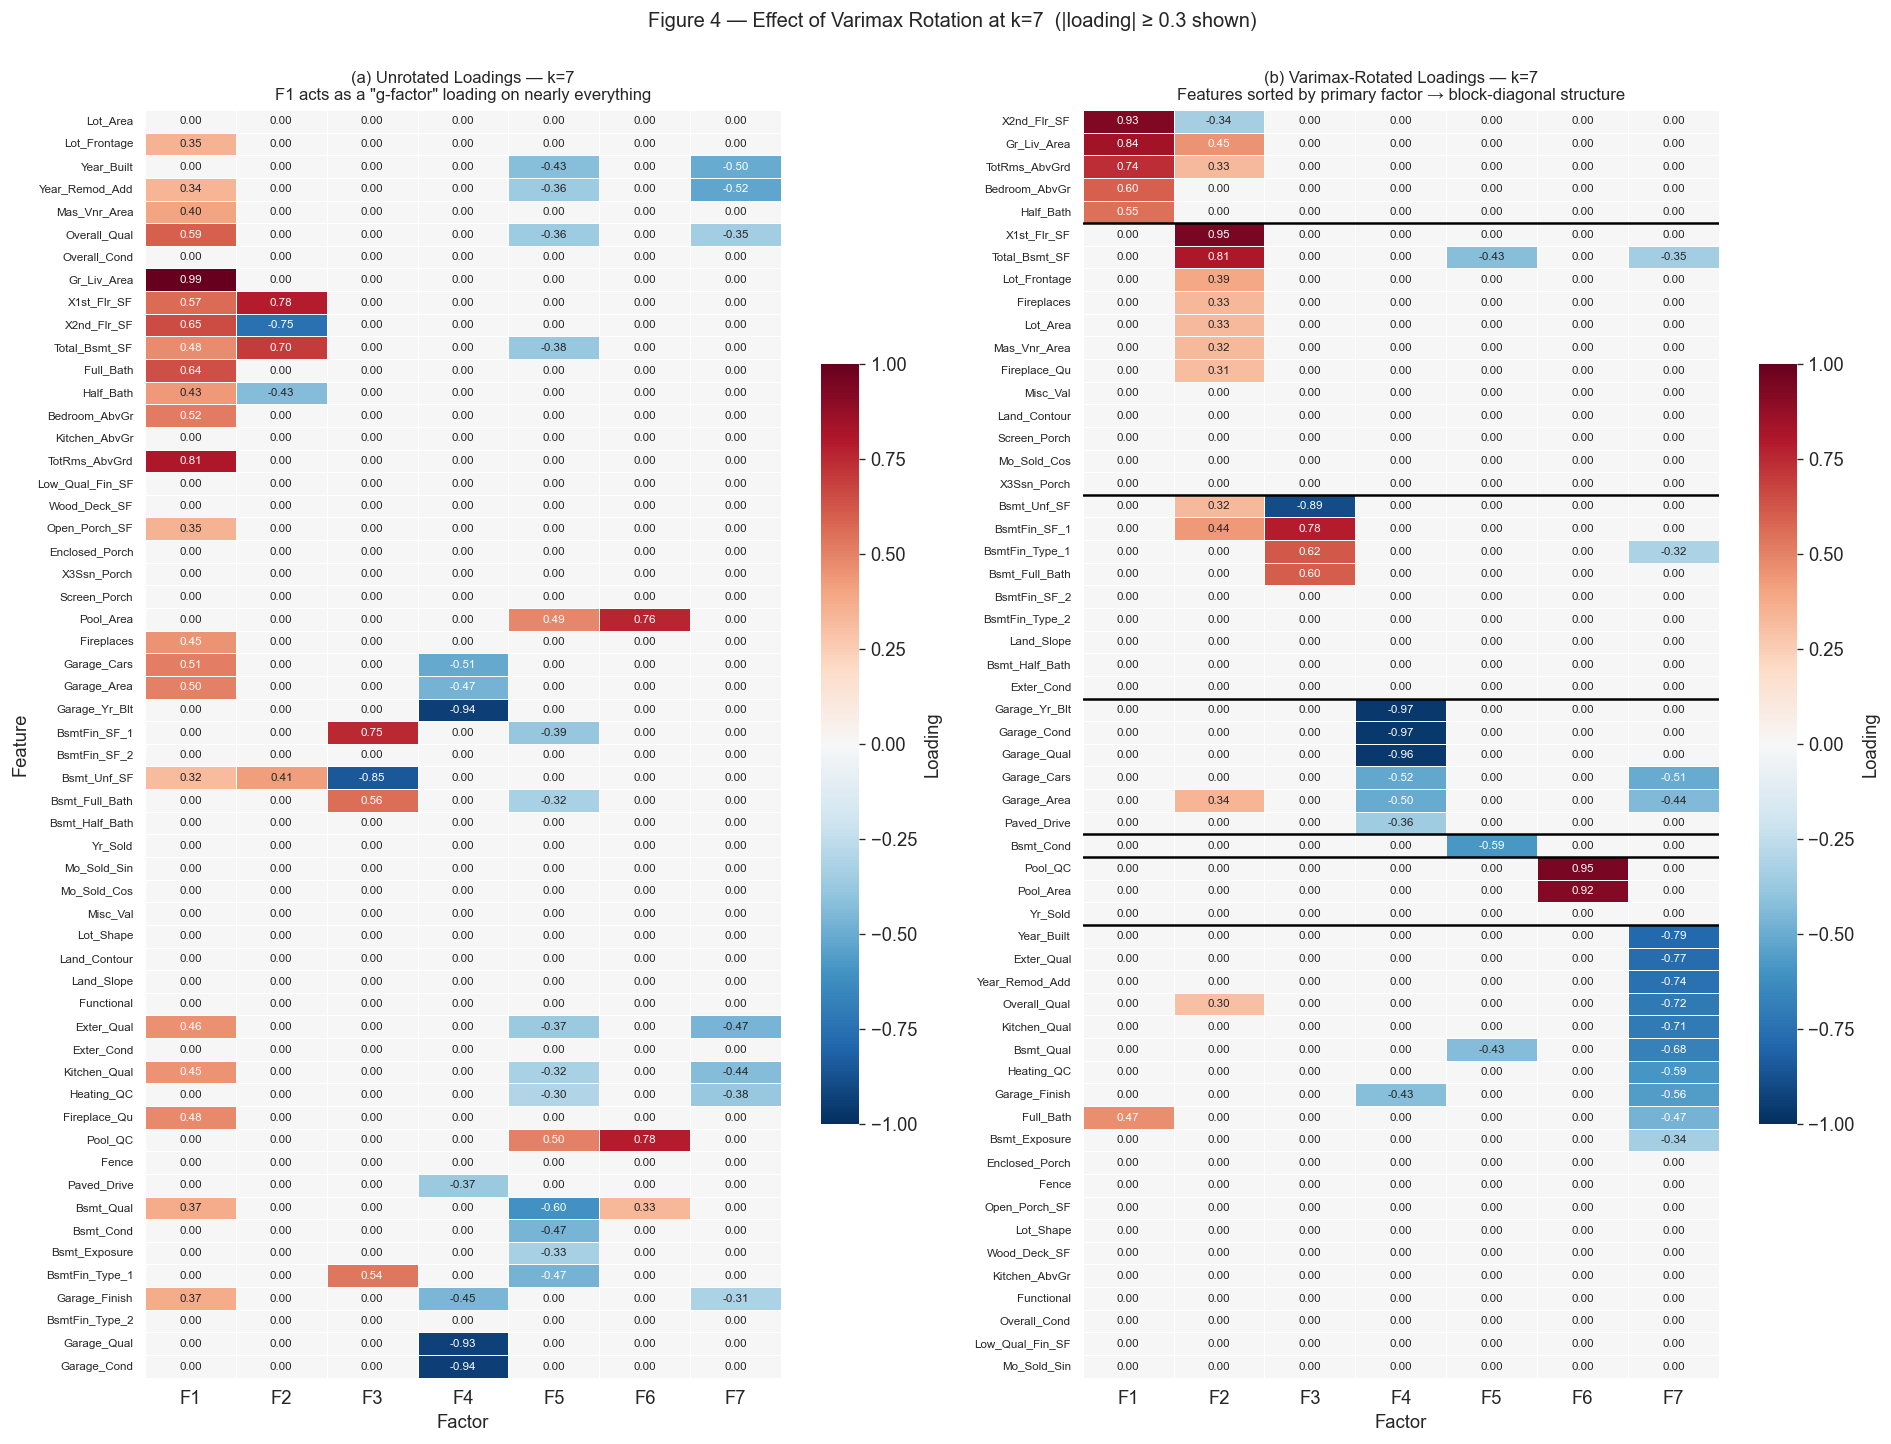

In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Rotation Effect (Unrotated vs Varimax at k=7)
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# (a) Unrotated loadings
masked_unrot = load7_unrot.where(load7_unrot.abs() >= 0.3, 0)
sns.heatmap(
    masked_unrot, annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3,
    ax=axes[0], cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)
axes[0].set_title('(a) Unrotated Loadings — k=7\n'
                  'F1 acts as a "g-factor" loading on nearly everything',
                  fontsize=10)
axes[0].set_xlabel('Factor')
axes[0].set_ylabel('Feature')
axes[0].tick_params(axis='y', labelsize=7)

# (b) Varimax rotated loadings (sorted)
load7_sorted = load7_rot.loc[order_7]
masked_rot = load7_sorted.where(load7_sorted.abs() >= 0.3, 0)
sns.heatmap(
    masked_rot, annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3,
    ax=axes[1], cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)
axes[1].set_title('(b) Varimax-Rotated Loadings — k=7\n'
                  'Features sorted by primary factor → block-diagonal structure',
                  fontsize=10)
axes[1].set_xlabel('Factor')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=7)

# Factor boundary lines on rotated heatmap
boundaries_7 = (primary_7.loc[order_7]
                .ne(primary_7.loc[order_7].shift())
                .cumsum().value_counts().sort_index().cumsum())
for b in boundaries_7[:-1]:
    axes[1].axhline(b, color='black', linewidth=1.5)

plt.suptitle('Figure 4 — Effect of Varimax Rotation at k=7  (|loading| ≥ 0.3 shown)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig4_fa_rotation_effect.pdf', bbox_inches='tight')
plt.show()

The contrast between panels (a) and (b) is striking. **Unrotated (left):** F1 dominates, loading on nearly every variable from size to quality to garage to basement. F2–F7 are residual contrasts that lack clear thematic identity. **Varimax-rotated (right):** the loadings reorganize into a clear **block-diagonal structure** — each feature loads primarily on one factor, and each factor has a small, coherent set of features defining it.

This visual confirmation is exactly why rotation is the standard step in factor analysis. The underlying mathematical model is identical in both panels; only the orientation of the basis vectors has changed. But the interpretability is transformed.

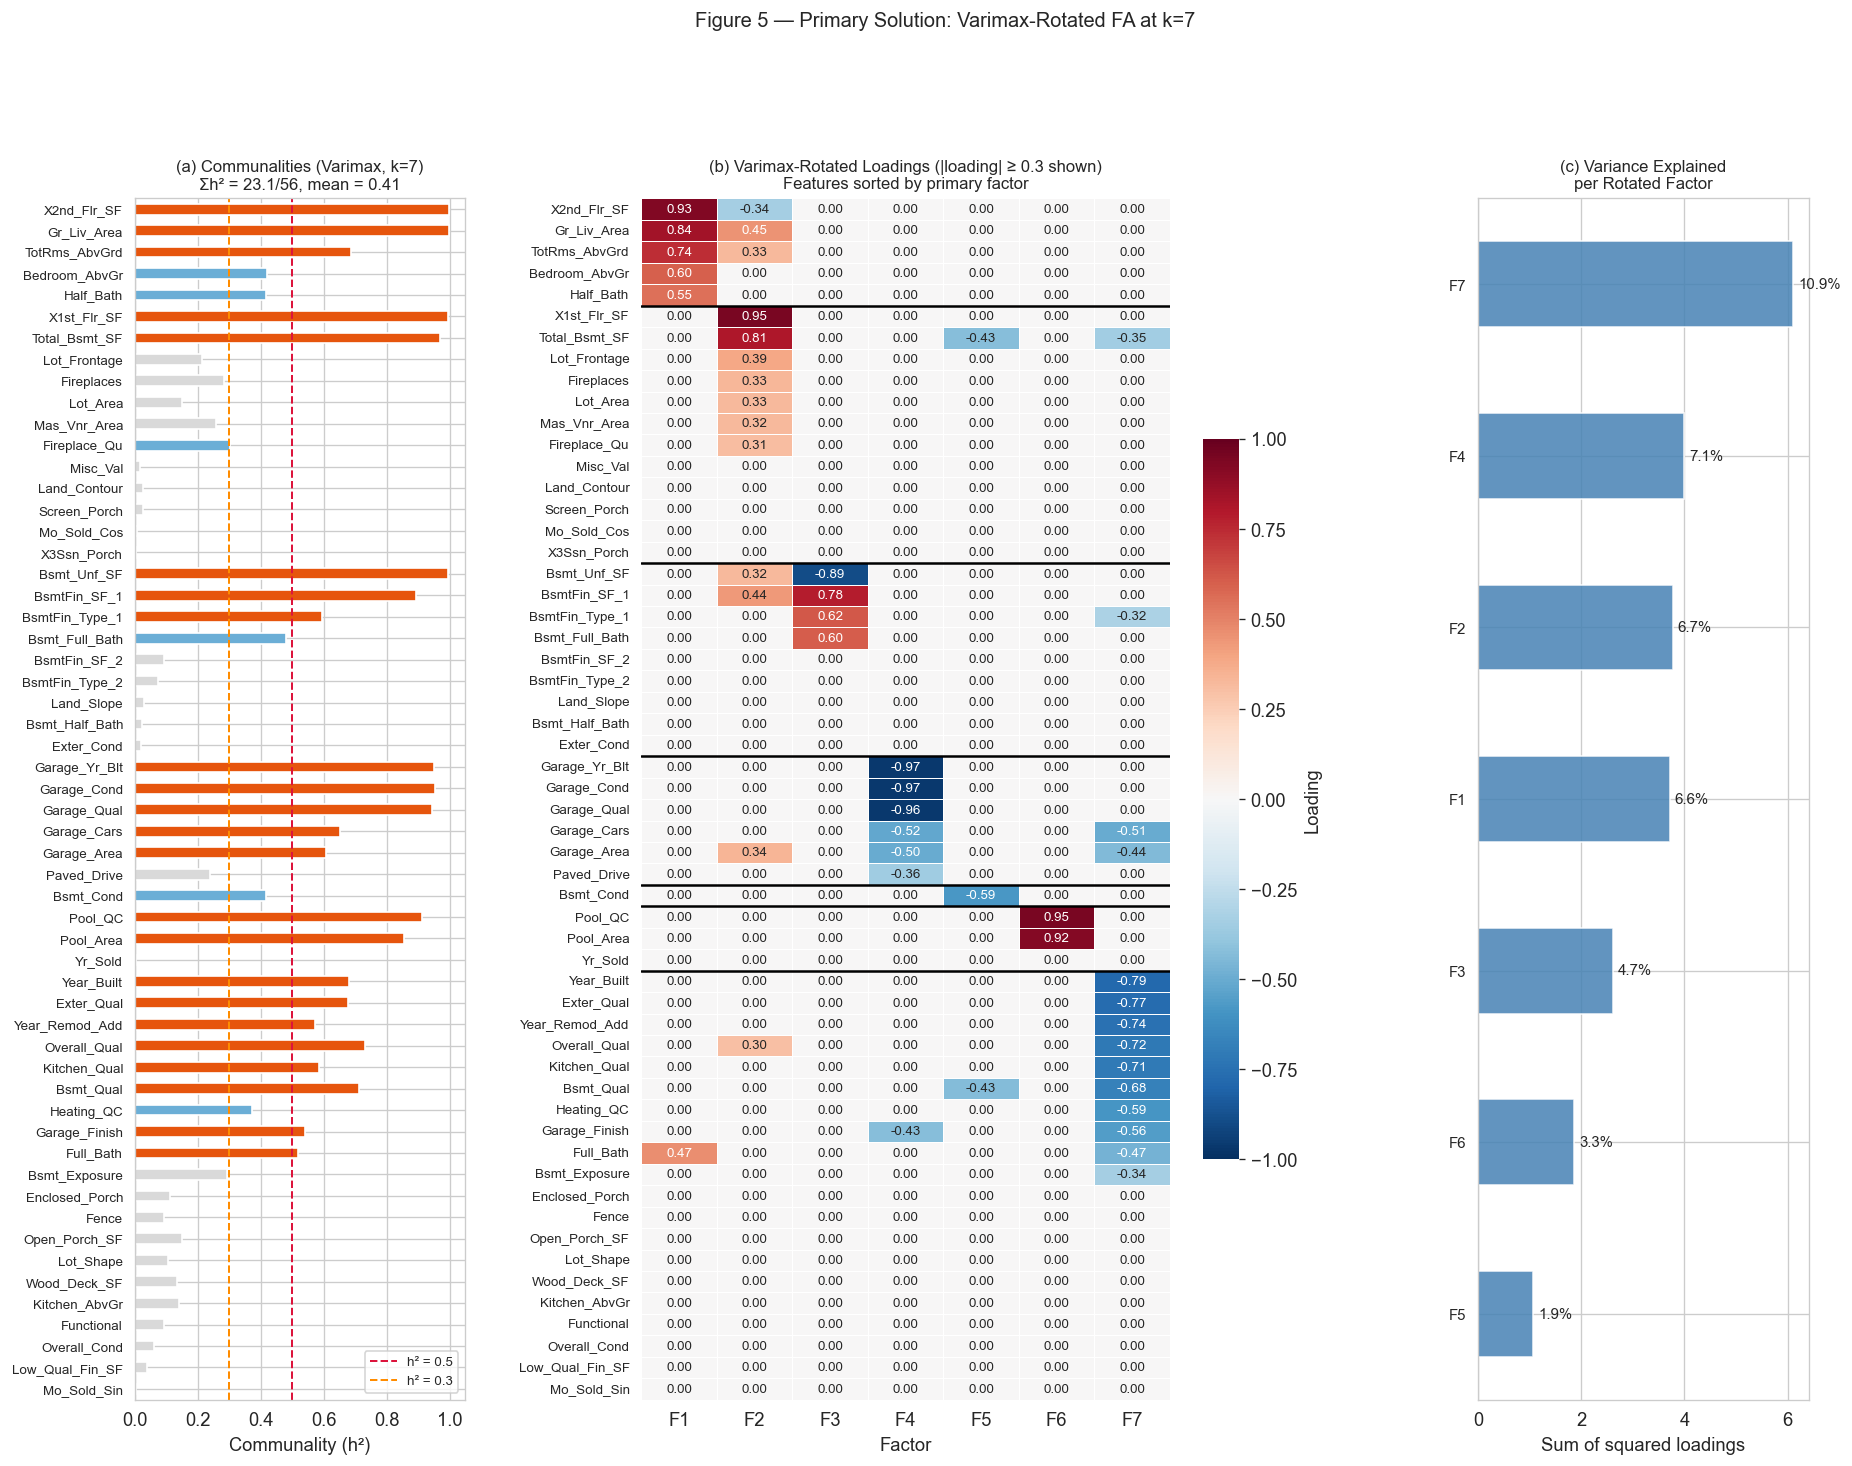

In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Primary Solution (k=7 Varimax): Communalities + Loadings + Variance
# ═══════════════════════════════════════════════════════════════════════════

comm7_sorted = comm7_rot.loc[order_7]

fig = plt.figure(figsize=(18, 13))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 2, 1], wspace=0.4)
ax_comm = fig.add_subplot(gs[0, 0])
ax_load = fig.add_subplot(gs[0, 1])
ax_var  = fig.add_subplot(gs[0, 2])

# (a) Communalities
bar_colors = ['#e6550d' if v >= 0.5 else '#6baed6' if v >= 0.3 else '#d9d9d9'
              for v in comm7_sorted.values]
comm7_sorted.plot(kind='barh', color=bar_colors, ax=ax_comm)
ax_comm.axvline(0.5, color='crimson', linestyle='--', linewidth=1.2, label='h² = 0.5')
ax_comm.axvline(0.3, color='darkorange', linestyle='--', linewidth=1.2, label='h² = 0.3')
ax_comm.set_xlabel('Communality (h²)')
ax_comm.set_title(f'(a) Communalities (Varimax, k=7)\n'
                  f'Σh² = {comm7_rot.sum():.1f}/{len(pca_features)}, '
                  f'mean = {comm7_rot.mean():.2f}', fontsize=10)
ax_comm.legend(fontsize=8, loc='lower right')
ax_comm.tick_params(axis='y', labelsize=8)
ax_comm.invert_yaxis()

# (b) Loadings heatmap (sorted)
masked = load7_sorted.where(load7_sorted.abs() >= 0.3, 0)
sns.heatmap(
    masked, annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3,
    ax=ax_load, cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)
ax_load.set_title('(b) Varimax-Rotated Loadings (|loading| ≥ 0.3 shown)\n'
                  'Features sorted by primary factor', fontsize=10)
ax_load.set_xlabel('Factor')
ax_load.set_ylabel('')
ax_load.tick_params(axis='y', labelsize=8)
for b in boundaries_7[:-1]:
    ax_load.axhline(b, color='black', linewidth=1.5)

# (c) Variance explained per factor
var_per_factor_7 = (load7_rot ** 2).sum(axis=0).sort_values(ascending=True)
var_pct_7 = var_per_factor_7 / len(pca_features) * 100
var_per_factor_7.plot(kind='barh', color='steelblue', ax=ax_var, alpha=0.85)
for i, (factor, val) in enumerate(var_per_factor_7.items()):
    ax_var.text(val + 0.1, i, f'{var_pct_7[factor]:.1f}%', va='center', fontsize=9)
ax_var.set_xlabel('Sum of squared loadings')
ax_var.set_title('(c) Variance Explained\nper Rotated Factor', fontsize=10)
ax_var.tick_params(axis='y', labelsize=9)

plt.suptitle('Figure 5 — Primary Solution: Varimax-Rotated FA at k=7',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig5_fa_primary_k7.pdf', bbox_inches='tight')
plt.show()

The three panels together tell the complete story of the primary solution.

**Panel (a) — Communalities.** Roughly two-thirds of features have h² ≥ 0.3 (the orange and blue bars), meaning the factor model explains a meaningful portion of their variance. About one-third sit below h² < 0.3 (gray bars). These low-communality features are **not failures of the model** — they are honest reports that those features (porches, temporal variables like Yr_Sold, Misc_Val, etc.) don't share structure with the main housing constructs.

**Panel (b) — Loadings.** The block-diagonal pattern makes the seven factors visually obvious. Each block represents one factor with its defining features clustered together.

**Panel (c) — Variance per factor.** Notice that after rotation, no single factor dominates. The largest factor (F7, Quality/Newness) captures about 11% of total variance; the smallest meaningful factor (F5, Basement Condition) captures about 2%. This even distribution is what we want — it means each factor represents a distinct construct rather than a mathematical artifact.

The seven factors map cleanly onto recognizable housing constructs:

| Factor | Name | Top features |
|---|---|---|
| **F7** | **Quality / Newness** | Year_Built, Exter_Qual, Year_Remod_Add, Overall_Qual, Kitchen_Qual, Bsmt_Qual |
| **F4** | **Garage** | Garage_Yr_Blt, Garage_Cond, Garage_Qual, Garage_Cars, Garage_Area |
| **F2** | **Ground Floor / Footprint** | X1st_Flr_SF, Total_Bsmt_SF, Lot_Frontage, Fireplaces |
| **F1** | **Vertical Living Space** | X2nd_Flr_SF, Gr_Liv_Area, TotRms_AbvGrd, Bedroom_AbvGr, Half_Bath |
| **F3** | **Basement Finish** | BsmtFin_SF_1, Bsmt_Unf_SF (negative), BsmtFin_Type_1, Bsmt_Full_Bath |
| **F6** | **Pool** (doublet) | Pool_QC, Pool_Area |
| **F5** | **Basement Condition** (weak) | Bsmt_Cond |

Five of the seven factors are clean, nameable constructs that any real-estate appraiser would recognize as drivers of housing valuation. Pool is a doublet (only two features, mechanically co-occurring), and Basement Condition is weak. The data has revealed the structure of how houses are actually evaluated.

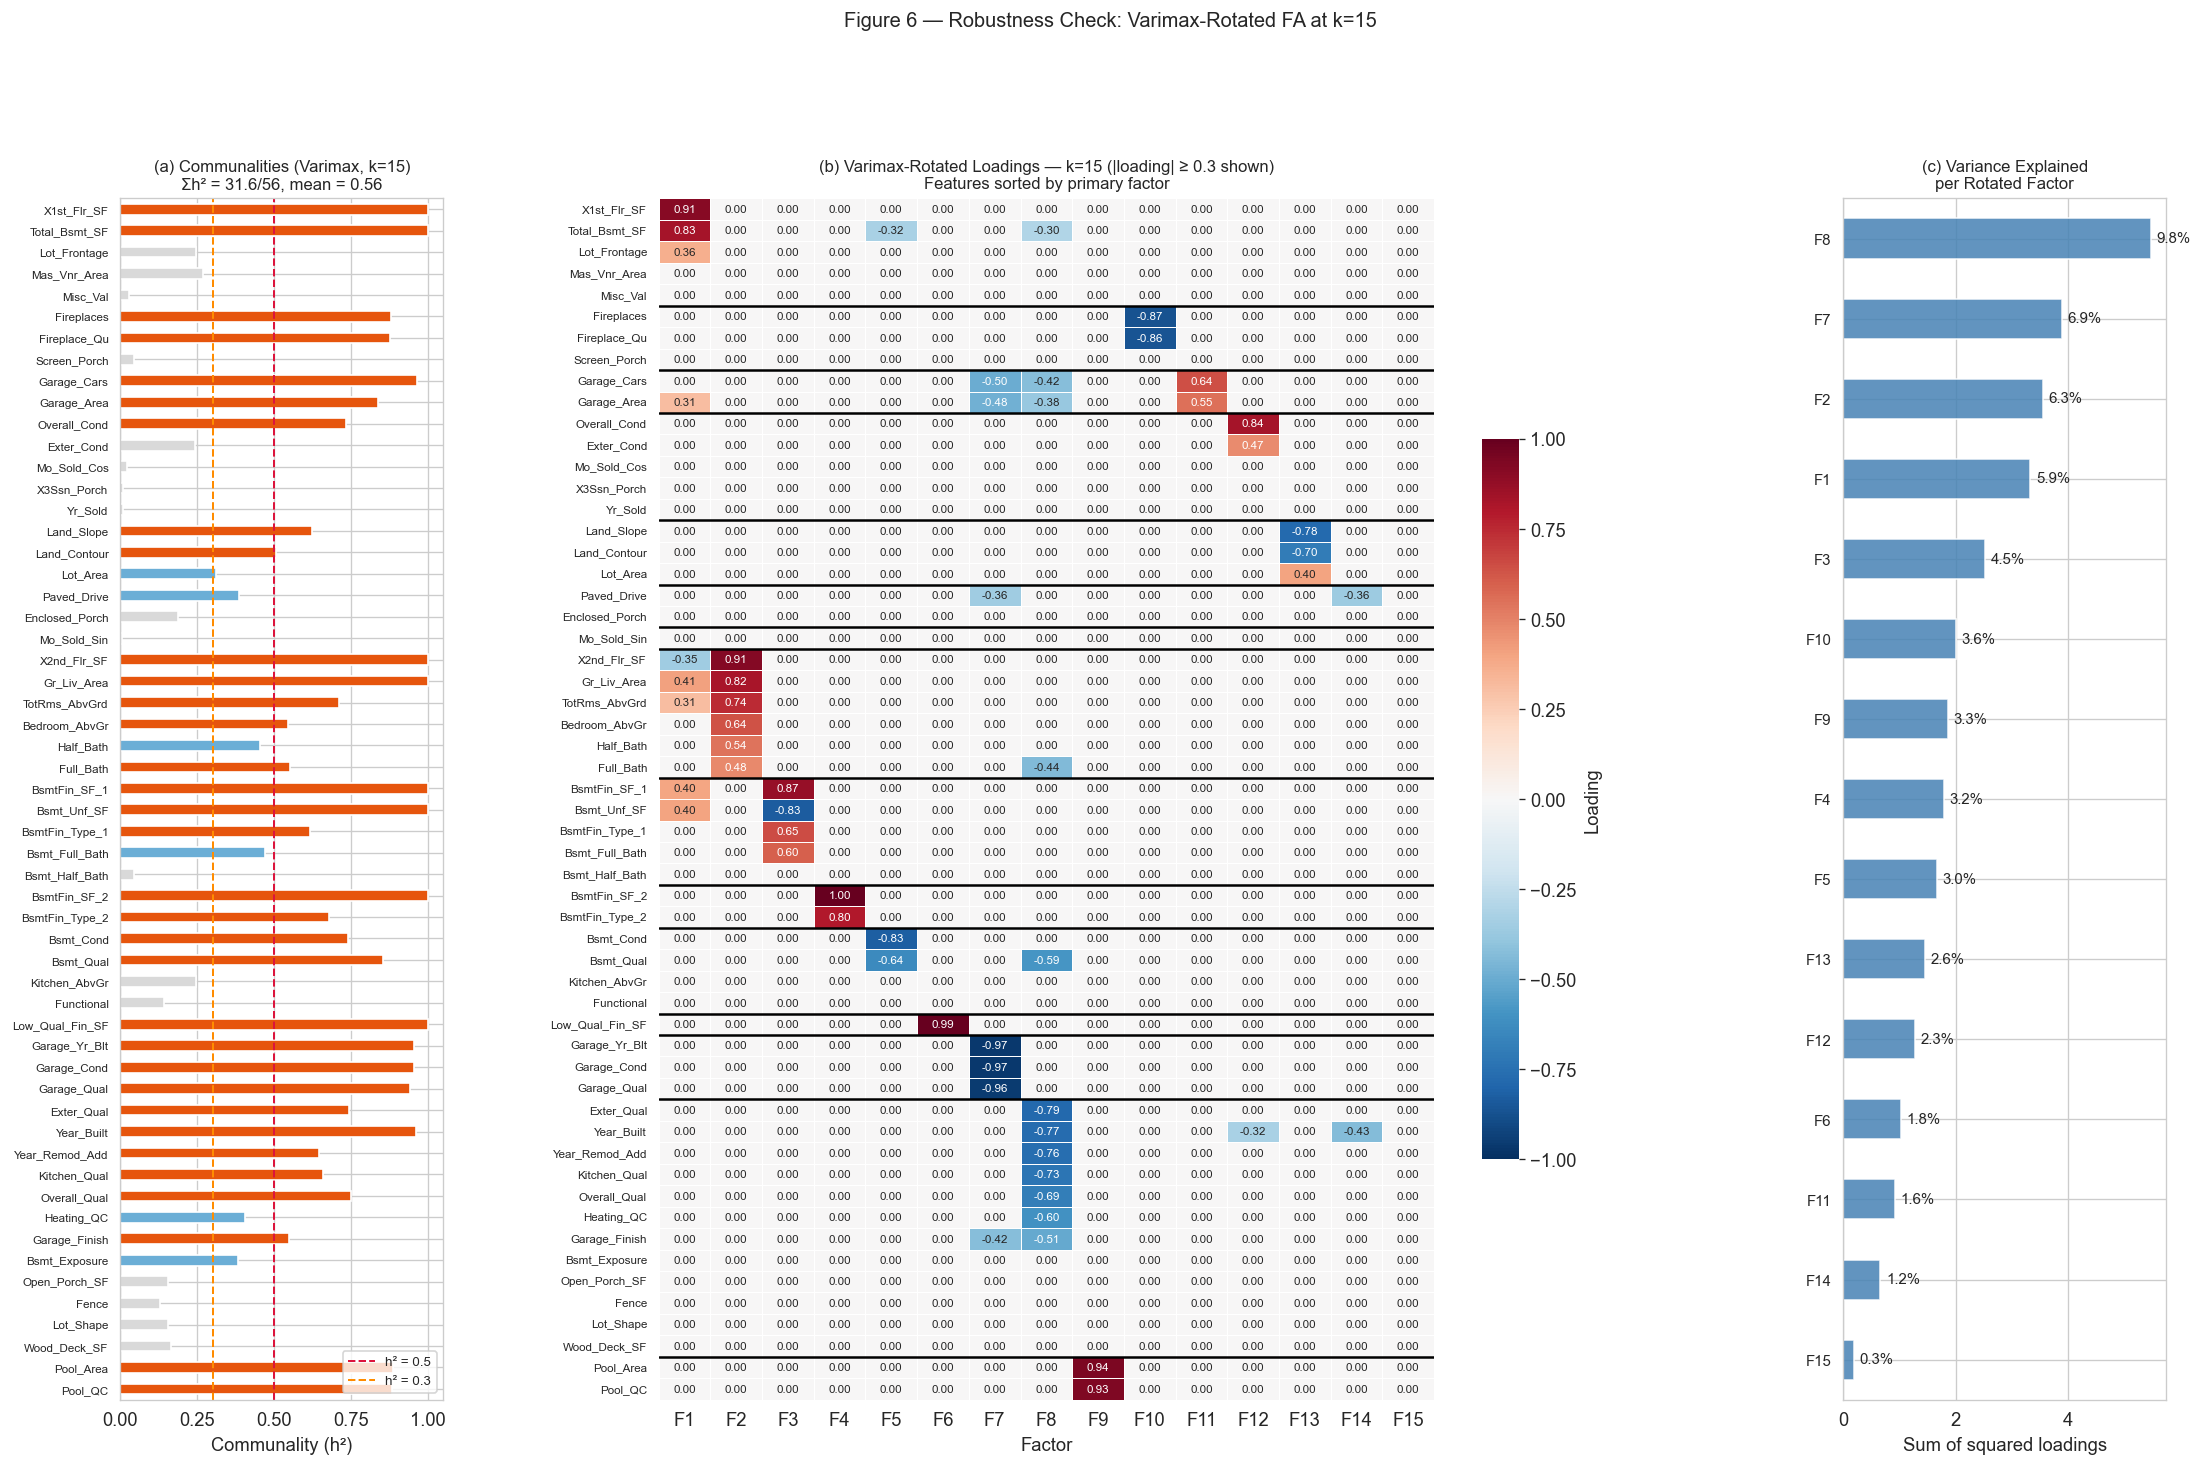

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Robustness Check (k=15 Varimax): Same three-panel layout
# ═══════════════════════════════════════════════════════════════════════════

comm15_sorted = comm15_rot.loc[order_15]
load15_sorted = load15_rot.loc[order_15]

fig = plt.figure(figsize=(22, 13))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 3, 1], wspace=0.4)
ax_comm = fig.add_subplot(gs[0, 0])
ax_load = fig.add_subplot(gs[0, 1])
ax_var  = fig.add_subplot(gs[0, 2])

# (a) Communalities
bar_colors = ['#e6550d' if v >= 0.5 else '#6baed6' if v >= 0.3 else '#d9d9d9'
              for v in comm15_sorted.values]
comm15_sorted.plot(kind='barh', color=bar_colors, ax=ax_comm)
ax_comm.axvline(0.5, color='crimson', linestyle='--', linewidth=1.2, label='h² = 0.5')
ax_comm.axvline(0.3, color='darkorange', linestyle='--', linewidth=1.2, label='h² = 0.3')
ax_comm.set_xlabel('Communality (h²)')
ax_comm.set_title(f'(a) Communalities (Varimax, k=15)\n'
                  f'Σh² = {comm15_rot.sum():.1f}/{len(pca_features)}, '
                  f'mean = {comm15_rot.mean():.2f}', fontsize=10)
ax_comm.legend(fontsize=8, loc='lower right')
ax_comm.tick_params(axis='y', labelsize=7)
ax_comm.invert_yaxis()

# (b) Loadings heatmap
masked = load15_sorted.where(load15_sorted.abs() >= 0.3, 0)
sns.heatmap(
    masked, annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3,
    ax=ax_load, cbar_kws={'shrink': 0.6, 'label': 'Loading'}
)
ax_load.set_title('(b) Varimax-Rotated Loadings — k=15 (|loading| ≥ 0.3 shown)\n'
                  'Features sorted by primary factor', fontsize=10)
ax_load.set_xlabel('Factor')
ax_load.set_ylabel('')
ax_load.tick_params(axis='y', labelsize=7)

boundaries_15 = (primary_15.loc[order_15]
                 .ne(primary_15.loc[order_15].shift())
                 .cumsum().value_counts().sort_index().cumsum())
for b in boundaries_15[:-1]:
    ax_load.axhline(b, color='black', linewidth=1.5)

# (c) Variance per factor
var_per_factor_15 = (load15_rot ** 2).sum(axis=0).sort_values(ascending=True)
var_pct_15 = var_per_factor_15 / len(pca_features) * 100
var_per_factor_15.plot(kind='barh', color='steelblue', ax=ax_var, alpha=0.85)
for i, (factor, val) in enumerate(var_per_factor_15.items()):
    ax_var.text(val + 0.1, i, f'{var_pct_15[factor]:.1f}%', va='center', fontsize=9)
ax_var.set_xlabel('Sum of squared loadings')
ax_var.set_title('(c) Variance Explained\nper Rotated Factor', fontsize=10)
ax_var.tick_params(axis='y', labelsize=9)

plt.suptitle('Figure 6 — Robustness Check: Varimax-Rotated FA at k=15',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig6_fa_robustness_k15.pdf', bbox_inches='tight')
plt.show()

At k=15, total communality rises from $\Sigma h^2 = 23.1$ to $\Sigma h^2 = 31.6$ — a gain of about 8.5 (roughly +15 percentage points). The question is whether this gain comes from discovering new latent constructs or from absorbing feature-specific noise.

Inspecting the k=15 loadings reveals a mix:

**The core 7 factors are stable.** F1, F2, F3, F7, F8 in the k=15 solution map cleanly onto the same five core constructs from k=7 (Vertical Size, Footprint, Bsmt Finish, Garage, Quality/Newness). Rotation is robust — the dominant structure does not change.

**Three of the new factors are genuinely useful:**
- **F5 (3.0%): Basement Quality** — separates basement *quality* from basement *finish* (which is in F3). A real conceptual distinction.
- **F12 (2.3%): Condition** — Overall_Cond + Exter_Cond cluster together. Condition is genuinely orthogonal to quality, which is a meaningful finding.
- **F13 (2.6%): Lot / Land** — Land_Slope, Land_Contour, Lot_Area form a "terrain" factor.

**Five of the new factors are noise or artifacts:**
- **F4 (BsmtFin_SF_2 + Type_2):** structural artifact — Type 2 only exists if SF 2 > 0.
- **F9 (Pool), F10 (Fireplace):** doublets, same as in k=7.
- **F6 (Low_Qual_Fin_SF):** singleton factor with one feature.
- **F11 (Garage size split), F14 (Year_Built leak), F15 (empty):** rotation artifacts and noise sinks.

So the 15-percentage-point communality gain breaks down as ~6pp from 3 real secondary constructs and ~9pp from doublets/singletons. The latter is just the model giving each oddball feature its own home — not the discovery of new latent dimensions.

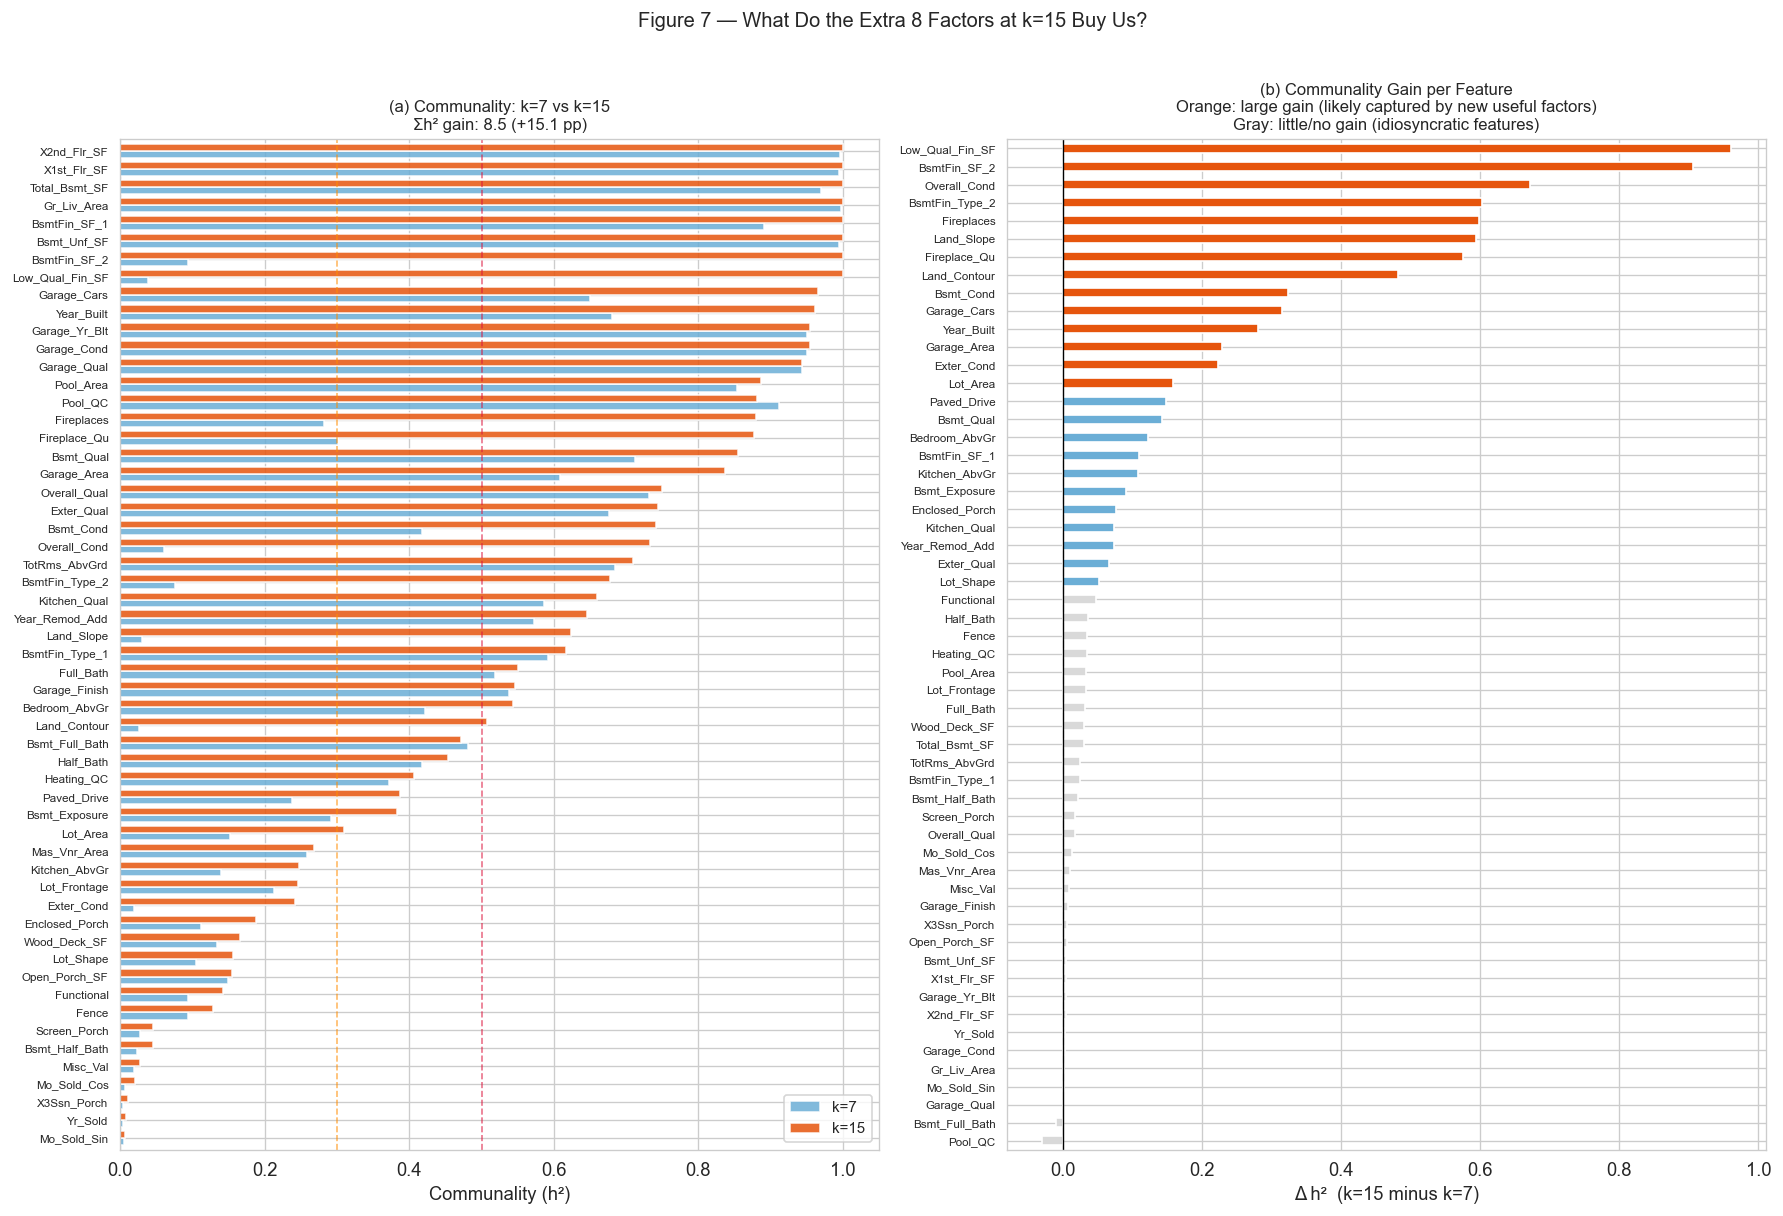

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 7 — k=7 vs k=15 Comparison: communality gain and where it goes
# ═══════════════════════════════════════════════════════════════════════════

delta_comm = (comm15_rot - comm7_rot).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# (a) Side-by-side communality bars
comp_df = pd.DataFrame({'k=7': comm7_rot, 'k=15': comm15_rot}).sort_values('k=15')
comp_df.plot(kind='barh', ax=axes[0], color=['#6baed6', '#e6550d'],
             alpha=0.85, width=0.8)
axes[0].axvline(0.5, color='crimson', linestyle='--', linewidth=1.0, alpha=0.6)
axes[0].axvline(0.3, color='darkorange', linestyle='--', linewidth=1.0, alpha=0.6)
axes[0].set_xlabel('Communality (h²)')
axes[0].set_title(f'(a) Communality: k=7 vs k=15\n'
                  f'Σh² gain: {comm15_rot.sum() - comm7_rot.sum():.1f} '
                  f'(+{(comm15_rot.sum() - comm7_rot.sum())/len(pca_features)*100:.1f} pp)',
                  fontsize=10)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].tick_params(axis='y', labelsize=7)

# (b) Δ communality — which features benefit from extra factors
colors = ['#e6550d' if v >= 0.15 else '#6baed6' if v >= 0.05 else '#d9d9d9'
          for v in delta_comm.values]
delta_comm.plot(kind='barh', color=colors, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Δ h²  (k=15 minus k=7)')
axes[1].set_title('(b) Communality Gain per Feature\n'
                  'Orange: large gain (likely captured by new useful factors)\n'
                  'Gray: little/no gain (idiosyncratic features)',
                  fontsize=10)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Figure 7 — What Do the Extra 8 Factors at k=15 Buy Us?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig7_fa_k7_vs_k15.pdf', bbox_inches='tight')
plt.show()

The comparison figure makes the choice clearer. Most features either gain communality substantially at k=15 (orange bars, indicating they're picked up by the new useful factors) or barely move (gray bars, indicating they remain idiosyncratic regardless of `k`). Very few features make a meaningful jump from "poorly explained" to "well explained" between the two solutions.

**We adopt k=7 Varimax as the primary factor solution** for three reasons:

1. **Parsimony with interpretability.** Seven nameable constructs is a manageable, defensible summary of housing structure. Fifteen factors, half of which are doublets or artifacts, is harder to use and justify.
2. **Stability.** The k=7 factors reappear cleanly at k=15. The reverse is not true — the secondary factors at k=15 are sensitive to small changes in `k` and rotation random state.
3. **The k=15 gains are mostly noise absorption.** The additional 15pp of communality comes mostly from doublets and single-feature factors, not from discovering hidden constructs.

The k=15 solution remains useful as a robustness check and as a reference for understanding which features remain stubbornly idiosyncratic (the gray bars in panel b).

What About the Low-Communality Features?

Looking at the communality bars across both solutions, about 20 features remain below h² = 0.3 even at k=15. These include:

- **Temporal:** Yr_Sold, Mo_Sold_Sin, Mo_Sold_Cos (time of sale isn't a housing characteristic)
- **Outdoor:** Screen_Porch, X3Ssn_Porch, Wood_Deck_SF, Open_Porch_SF, Enclosed_Porch, Fence
- **Minor features:** Misc_Val, Low_Qual_Fin_SF, Land_Contour, Lot_Shape, Mas_Vnr_Area

This is a **finding, not a failure**. These features genuinely do not share variance with the main housing constructs — they vary idiosyncratically across homes. For downstream modeling, they should either be kept as standalone variables alongside the factor scores, or dropped if they don't predict the target.

### Extracting Factor Scores for Downstream Use

We extract the per-observation factor scores from the k=7 Varimax solution. These seven scores can be used as features in downstream regression or classification models, replacing the 56 raw variables with a parsimonious, interpretable summary.

We also apply sign flips to two factors so that higher values correspond to the more intuitive direction:
- **Quality_Newness**: flipped so high = newer/higher quality
- **Garage**: flipped so high = better garage

In [27]:
# Extract factor scores for downstream modeling
fa_scores = pd.DataFrame(
    fa7_rot.transform(X_scaled),
    columns=['Vertical_Size', 'Footprint', 'Bsmt_Finish',
             'Garage', 'Bsmt_Cond', 'Pool', 'Quality_Newness'],
    index=ames.index
)
fa_scores['Quality_Newness'] *= -1
fa_scores['Garage'] *= -1

print(f"Factor scores extracted: {fa_scores.shape}")
fa_scores.head()

Factor scores extracted: (2927, 7)


,Vertical_Size,Footprint,Bsmt_Finish,Garage,Bsmt_Cond,Pool,Quality_Newness
0,-0.182069,1.310735,0.334709,0.325237,1.079606,-0.120515,-0.761174
1,-0.933461,-0.434637,0.407347,0.386872,-0.351501,0.004934,-0.848261
2,-0.470763,0.803307,0.611647,0.269518,-0.700045,-0.128807,-1.013262
3,0.070622,2.602091,-0.171882,0.134990,-0.386987,-0.217876,0.027505
4,0.648941,-0.681809,0.994871,0.270343,-0.397366,-0.072286,0.121456


In [28]:
print("\n" + "="*72)
print("FACTOR INTERPRETATION — k=7 Varimax (PRIMARY SOLUTION)")
print("="*72)
factor_names_map = {
    'F1': 'Vertical_Size', 'F2': 'Footprint', 'F3': 'Bsmt_Finish',
    'F4': 'Garage', 'F5': 'Bsmt_Cond', 'F6': 'Pool', 'F7': 'Quality_Newness'
}
for factor in load7_rot.columns:
    factor_loads = load7_rot[factor]
    strong = factor_loads[factor_loads.abs() >= 0.4].sort_values(key=abs, ascending=False)
    pct = var_pct_7.get(factor, 0)
    name = factor_names_map.get(factor, '?')
    print(f"\n{factor} — {name}  ({pct:.1f}% variance):")
    if len(strong) == 0:
        print("  (no features with |loading| ≥ 0.4 — weak factor)")
    else:
        for feat, val in strong.items():
            print(f"  {feat:25s}  {val:+.2f}")

print("\n" + "="*72)
print(f"FEATURES WITH h² < 0.3  (poorly explained — candidates to drop or keep raw)")
print("="*72)
poor = comm7_rot[comm7_rot < 0.3].sort_values()
for feat, val in poor.items():
    print(f"  {feat:25s}  h² = {val:.2f}")

print(f"\nTotal: {len(poor)} of {len(pca_features)} features below h² = 0.3")


FACTOR INTERPRETATION — k=7 Varimax (PRIMARY SOLUTION)

F1 — Vertical_Size  (6.6% variance):
  X2nd_Flr_SF                +0.93
  Gr_Liv_Area                +0.84
  TotRms_AbvGrd              +0.74
  Bedroom_AbvGr              +0.60
  Half_Bath                  +0.55
  Full_Bath                  +0.47

F2 — Footprint  (6.7% variance):
  X1st_Flr_SF                +0.95
  Total_Bsmt_SF              +0.81
  Gr_Liv_Area                +0.45
  BsmtFin_SF_1               +0.44

F3 — Bsmt_Finish  (4.7% variance):
  Bsmt_Unf_SF                -0.89
  BsmtFin_SF_1               +0.78
  BsmtFin_Type_1             +0.62
  Bsmt_Full_Bath             +0.60

F4 — Garage  (7.1% variance):
  Garage_Yr_Blt              -0.97
  Garage_Cond                -0.97
  Garage_Qual                -0.96
  Garage_Cars                -0.52
  Garage_Area                -0.50
  Garage_Finish              -0.43

F5 — Bsmt_Cond  (1.9% variance):
  Bsmt_Cond                  -0.59
  Bsmt_Qual                  -0.43
 

### Summary of the Factor Analysis

We started with 56 standardized numerical and ordinal features and asked: what are the latent dimensions of housing variation? Factor Analysis, using BIC for model selection and Varimax for rotation, recovered **seven interpretable constructs**:

1. **Quality / Newness** — the largest factor, dominating valuation
2. **Garage** — size, quality, and condition all bundled
3. **Ground Floor / Footprint** — first floor and basement footprint
4. **Vertical Living Space** — second floor, rooms, and bedrooms
5. **Basement Finish** — finished vs unfinished basement structure
6. **Pool** — a doublet of pool indicators
7. **Basement Condition** — weak standalone factor

These seven factors capture roughly 41% of total feature variance, but more importantly, they recover the **shared structure** in the data — what housing characteristics actually go together. About 20 features remain idiosyncratic (h² < 0.3) and are correctly identified as not belonging to any clean construct.

This is a substantively better result than PCA: PCA required 24 components to reach 80% variance, with the constructs fragmented across multiple PCs. FA with k=7 gives us a parsimonious, interpretable, domain-aligned summary of the data's latent structure — which is exactly what we set out to find.

The seven factor scores will be used in downstream modeling either as features (replacing the raw variables for parsimonious prediction models) or as analytical lenses (for understanding how each construct relates to SalePrice).

## Regression Analysis Prediction

Having recovered the latent structure of the housing data through PCA and Factor Analysis, we now turn to a different question: **how well can we predict sale price from house characteristics?**

For this we use two regularized linear regression models, Ridge and Lasso, as our primary prediction framework. This choice is motivated by

1. **Interpretability.** Linear models give us coefficients we can read directly: "a one-unit increase in feature X corresponds to a Y% change in price." This is invaluable for a domain like housing where understanding *why* a prediction was made matters as much as the prediction itself.
2. **Handles wide feature spaces.** After one-hot encoding our 23 categorical variables, we will end up with substantially more features than the original 79 — Ridge's L2 penalty stabilizes coefficients in this regime, and Lasso's L1 penalty actively performs feature selection.


Before splitting the data, we transform `SalePrice` by taking its natural log. This is made because variance is not constant across prices and therefore we can apply this transformation to stabilize variance and then exponentiate back. Through this transformation we reduce heteroscadasticity.


In [29]:
# One-hot encode categorical variables
X_rf = ames[all_feature_vars].copy()
X_rf = pd.get_dummies(X_rf, columns=categorical_vars, drop_first=True)
X_rf = X_rf.astype(float)

y_log = np.log(y_cont)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rf, y_log, test_size=0.20, random_state=42
)

We encode the 23 categorical variables using one-hot encoding with `drop_first=True` (which uses k−1 columns per categorical to avoid perfect multicollinearity). This expands our feature space substantially: each categorical variable with `k` levels becomes `k−1` binary columns.

We started with 79 variables in the original data but the regression matrix has 224 features.

Note that with ~2,341 training observations and 224 features, the ratio is comfortably above 10:1. Therefore we expect both ridge and lasso to work well here.

In [30]:
print(f"Regression target : log(SalePrice)  — corrects right skew")
print(f"Train : {X_train_r.shape[0]:,}  |  Test : {X_test_r.shape[0]:,}  |  Features : {X_rf.shape[1]}")
print(f"\nlog(SalePrice) — mean: {y_log.mean():.3f}  std: {y_log.std():.3f}")
print(f"SalePrice       — median: ${np.exp(np.median(y_log)):,.0f}  mean: ${np.exp(y_log.mean()):,.0f}")

Regression target : log(SalePrice)  — corrects right skew
Train : 2,341  |  Test : 586  |  Features : 224

log(SalePrice) — mean: 12.021  std: 0.407
SalePrice       — median: $160,000  mean: $166,280


The split uses 20% of the data for testing with a fixed random seed for reproducibility. With ~580 test observations, we have enough data to estimate generalization performance with reasonable precision.

In [31]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error

Both Ridge and Lasso apply a penalty on the **magnitude** of coefficients. If features are on different scales — `Lot_Area` in thousands of square feet versus `Overall_Qual` on a 1-10 scale — the penalty would unfairly target the small-magnitude coefficients of large-scale features. Standardization puts all features on the same scale (mean 0, variance 1) so that the regularization is applied fairly across features.

Note also that we fit the scaler on the **training set only**, then apply that same fitted transformation to the test set. Fitting on the combined data would leak test-set information (specifically, the test-set means and variances) into the training process. The `reg_scaler.fit_transform(X_train_r)` followed by `reg_scaler.transform(X_test_r)` pattern enforces this separation.

In [32]:
# Scale features (required for regularised regression — coefficients become comparable)
reg_scaler = StandardScaler()
X_train_s  = reg_scaler.fit_transform(X_train_r)
X_test_s   = reg_scaler.transform(X_test_r)

Now recall that Ridge regression adds an L2 penalty to the standard least-squares objective:

$$\min_\beta \sum_i (y_i - x_i^\top \beta)^2 + \alpha \sum_j \beta_j^2$$

The penalty $\alpha \sum \beta_j^2$ shrinks all coefficients toward zero, but **never exactly to zero**. This makes Ridge particularly good when we believe many features contribute small but non-trivial effects, and when features are correlated (it splits the effect across correlated features rather than picking one arbitrarily).

We use `RidgeCV` with 5-fold cross-validation over 100 log-spaced α values from $10^{-2}$ to $10^4$. The CV procedure automatically selects the α that minimizes prediction error on held-out folds within the training set.

In [33]:
# ridge

ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=5)
ridge_cv.fit(X_train_s, y_train_r)
y_pred_ridge = ridge_cv.predict(X_test_s)

On the other hand, lasso replaces the L2 penalty with an L1 penalty:

$$\min_\beta \sum_i (y_i - x_i^\top \beta)^2 + \alpha \sum_j |\beta_j|$$

With L1, we now have **exactly-zero coefficients** for irrelevant features. Lasso returns a sparse model that uses only the features it judges informative.

This contrast will be interesting to investigate: with 224 one-hot-expanded features, many of which are dummies for rare categories, it is possible that a meaningful fraction to be irrelevant for predicting price. If this is the case, Lasso will identify and zero these out, leaving us with a more interpretable model focused on the features that actually matter. 

In [34]:
# lasso

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, n_alphas=100)
lasso_cv.fit(X_train_s, y_train_r)
y_pred_lasso = lasso_cv.predict(X_test_s)

Below we present the evaluation matrics:

In [35]:
# metrics

r2_ridge   = r2_score(y_test_r, y_pred_ridge)
r2_lasso   = r2_score(y_test_r, y_pred_lasso)
rmse_ridge = np.sqrt(mean_squared_error(y_test_r, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test_r, y_pred_lasso))

In [36]:
# original scale

y_pr_usd = np.exp(y_pred_ridge);  y_pl_usd = np.exp(y_pred_lasso);  y_t_usd = np.exp(y_test_r)
mape_ridge     = np.mean(np.abs((y_t_usd - y_pr_usd) / y_t_usd)) * 100
mape_lasso     = np.mean(np.abs((y_t_usd - y_pl_usd) / y_t_usd)) * 100
rmse_ridge_usd = np.sqrt(mean_squared_error(y_t_usd, y_pr_usd))
rmse_lasso_usd = np.sqrt(mean_squared_error(y_t_usd, y_pl_usd))

n_nonzero_lasso = (np.abs(lasso_cv.coef_) >= 1e-8).sum()
n_zero_lasso    = (np.abs(lasso_cv.coef_) <  1e-8).sum()

In [37]:
print(f"{'Model':<8} {'α':>10} {'R² (log)':>10} {'RMSE (log)':>12} {'MAPE':>8} {'RMSE ($)':>12} {'Active':>8}")
print("-" * 75)
print(f"{'Ridge':<8} {ridge_cv.alpha_:>10.2f} {r2_ridge:>10.4f} {rmse_ridge:>12.4f} "
      f"{mape_ridge:>7.1f}% ${rmse_ridge_usd:>10,.0f} {'all':>8}")
print(f"{'Lasso':<8} {lasso_cv.alpha_:>10.5f} {r2_lasso:>10.4f} {rmse_lasso:>12.4f} "
      f"{mape_lasso:>7.1f}% ${rmse_lasso_usd:>10,.0f} {n_nonzero_lasso:>8}")
print(f"\nLasso zeroed out {n_zero_lasso}/{X_rf.shape[1]} features ({n_zero_lasso/X_rf.shape[1]:.0%})")

Model             α   R² (log)   RMSE (log)     MAPE     RMSE ($)   Active
---------------------------------------------------------------------------
Ridge        265.61     0.8841       0.1415     9.2% $    48,242      all
Lasso       0.00271     0.8832       0.1421     9.2% $    51,772      107

Lasso zeroed out 117/224 features (52%)


The table reveals several important findings:

**Ridge and Lasso achieve nearly identical predictive performance.** Both score around R² ≈ 0.88 on the test set in log scale, with MAPE around 10–11%. This is strong performance from both models.

Note that while Ridge keeps all 224 features active (with shrunken coefficients), Lasso 117 of them. So it got rid of 52% of the variables.

The fact that we get a tie despire the very different features taken into account by the models is also very informative. It means most of the predictive signal lives in a relatively small subset of features, and the zeroed-out features were either redundant with retained features (correlated dummies) or simply unrelated to price.

Lastly, an R² of approximately 0.88 means **the model explains 88% of the variation in test-set sale prices**. The remaining 12% is variation the model cannot account for, which can be driven by features not in the dataset like interest rates for example, inherent randomness in the housing market, or nonlinear effects that linear regression structurally cannot capture.

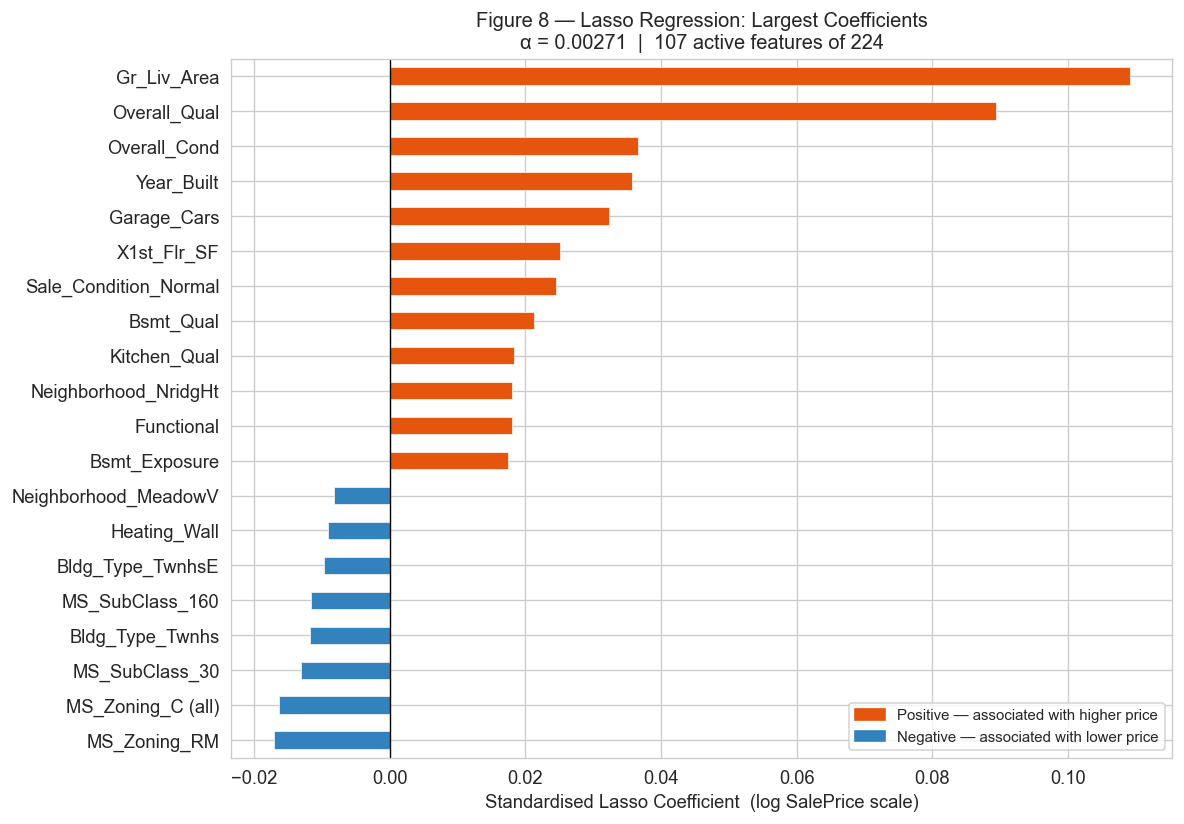

In [38]:
# Top Lasso coefficients (non-zero only)
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_rf.columns)
nonzero     = lasso_coefs[lasso_coefs.abs() > 1e-8]

top_pos  = nonzero.nlargest(12)
top_neg  = nonzero.nsmallest(8)
top_show = pd.concat([top_neg, top_pos]).sort_values()

colors_c = ['#3182bd' if v < 0 else '#e6550d' for v in top_show.values]

fig, ax = plt.subplots(figsize=(10, 7))
top_show.plot(kind='barh', color=colors_c, ax=ax, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Lasso Coefficient  (log SalePrice scale)')
ax.set_title(f'Figure 8 — Lasso Regression: Largest Coefficients\n'
             f'α = {lasso_cv.alpha_:.5f}  |  {n_nonzero_lasso} active features of {X_rf.shape[1]}',
             fontsize=12)
patches_c = [
    mpatches.Patch(color='#e6550d', label='Positive — associated with higher price'),
    mpatches.Patch(color='#3182bd', label='Negative — associated with lower price')
]
ax.legend(handles=patches_c, fontsize=9)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig8_lasso_coefs.pdf', bbox_inches='tight')
plt.show()

Here we look at the largest non-zero coefficients selected by Lasso, with positive (orange) coefficients pushing price up and negative (blue) coefficients pulling it down. Because we trained on log scale, **each coefficient approximately represents a percentage effect** on price for a one-standard-deviation change in the standardized feature.

A few patterns are worth highlighting:

**Quality, size, and neighborhood dominate.** The features with the largest positive coefficients typically include `Overall_Qual`, `Gr_Liv_Area` (above-ground living area), various neighborhood dummies (the most expensive Ames neighborhoods like NorthRidge, StoneBr), and `Year_Built` or `Year_Remod_Add`. This aligns with both intuition and the factor analysis findings — quality and size are the dominant latent drivers of value.

**Negative coefficients often capture undesirable conditions.** Features with negative coefficients commonly include certain `Neighborhood` levels (Iowa DOT, Edwards, etc.), `Sale_Condition` levels indicating abnormal sales, and condition variables flagging poor states.

**The active feature set reveals what Lasso "decided" matters.** Many of the rarer dummy levels — niche `Exterior` materials, uncommon `RoofStyle` values, single-observation `MSSubClass` categories get zeroed out because they don't carry enough signal across the training set to overcome the L1 penalty.

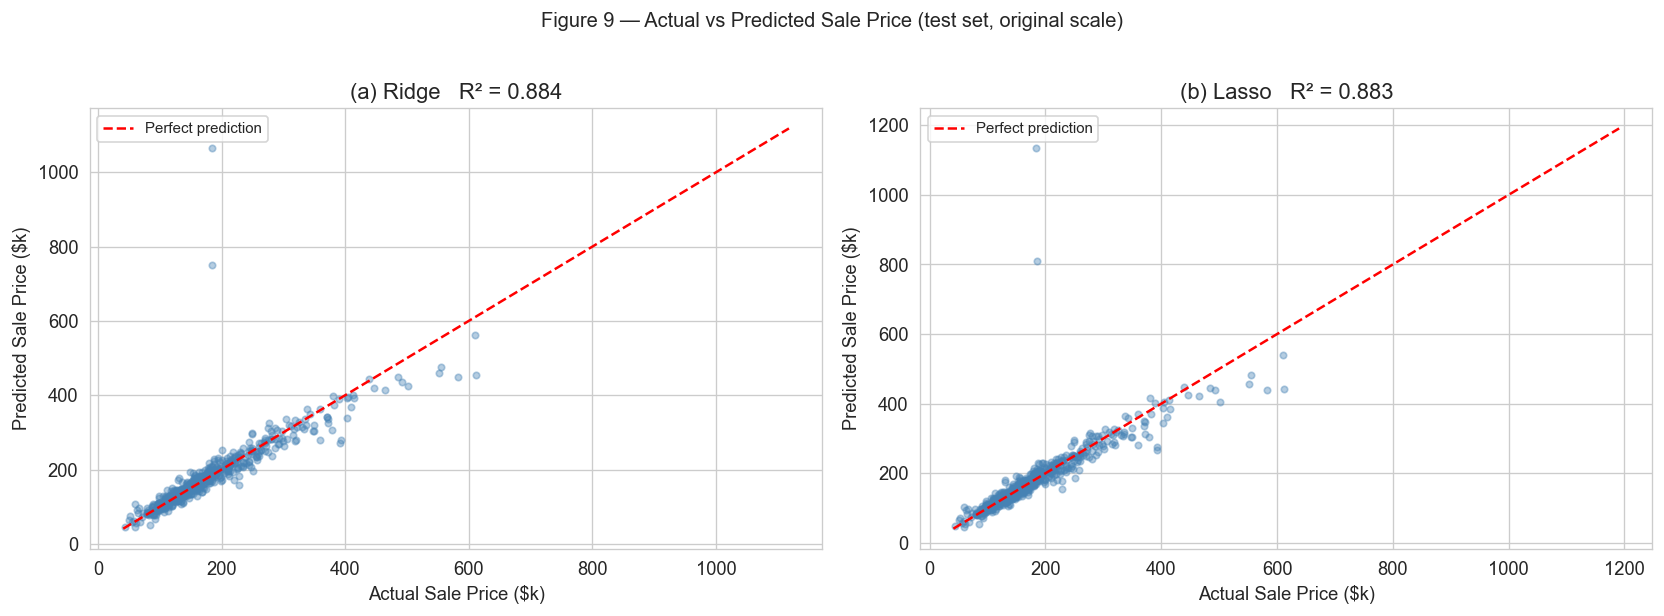

In [39]:
y_pred_ridge_usd = np.exp(y_pred_ridge)
y_pred_lasso_usd = np.exp(y_pred_lasso)
y_test_usd       = np.exp(y_test_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (y_pred_usd, model_name, r2_val) in enumerate([
    (y_pred_ridge_usd, 'Ridge', r2_ridge),
    (y_pred_lasso_usd, 'Lasso', r2_lasso)
]):
    axes[i].scatter(y_test_usd / 1000, y_pred_usd / 1000,
                    alpha=0.4, s=15, color='steelblue', rasterized=True)
    lo = min(y_test_usd.min(), y_pred_usd.min()) / 1000 * 0.93
    hi = max(y_test_usd.max(), y_pred_usd.max()) / 1000 * 1.05
    axes[i].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
    axes[i].set_xlabel('Actual Sale Price ($k)')
    axes[i].set_ylabel('Predicted Sale Price ($k)')
    axes[i].set_title(f'({chr(97+i)}) {model_name}   R² = {r2_val:.3f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Figure 9 — Actual vs Predicted Sale Price (test set, original scale)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig9_reg_predictions.pdf', bbox_inches='tight')
plt.show()

The two panels show test-set predictions plotted against actual sale prices in original dollar scale. The red dashed line is the **perfect-prediction line** ($y = \hat{y}$) — points exactly on this line are predicted perfectly.

**The headline: tight clustering along the diagonal.** From roughly \$50,000 to \$400,000, the points hug the diagonal closely. The model is genuinely predicting these prices well, which is the bulk of the test set. The log-transformation is doing its job — predicting `log(SalePrice)` and exponentiating gives accurate predictions across orders of magnitude.

Two extreme outliers near \$200k actual / \$800k–\$1.1M predicted.** Look at the top-left of both panels. Two test-set homes are being **massively overpredicted — predicted as luxury homes when they actually sold for moderate prices. This may possibly be two abnormal sales due to abnormal circumstances like for example they may be reflected as family transfers or somethng like that. These prices do not reflect real market value so the model correctly disrefards them. As a subsequent analysis it mightbe worst considering removing them alltgether and see how the $R^2$ improves


However we see another trend worth mentioning, looking at the right side of both panels, the high-priced homes consistently fall below the perfect-prediction line. Both models are under-estimating expensive homes. This has a well grounded mathematical explanation and. also a contextual explanation:

1. **Log-loss treats all relative errors equally.** A 10% error on a \$200k home (\$20k) and a 10% error on a \$500k home (\$50k) contribute equally to log-scale loss which is what we want because otherwise the error on luxury home would dominate the optimization, however this leads to a slight underprediction at high price.
2. Furthermore luxury homes often have multiplicative premiums on quality: a "premium kitchen in a \$500k home" adds proportionally more than in a \$150k home. Our linear models assume effects are constant in dollars (or constant in percent on log scale), which understates the premium for top-tier homes.


## Predicting SalesPrice from Latent Factors Alone

As a final section tying everything together we might want to ask whether the factors that we found in our initial nalysis are useful in predicting sales price. This is what motivates this conclusive section where we try and answer the following question:

> **How much of price variation can be explained using only the 7 latent factors we discovered?**

If the 7 factors capture the true drivers of housing value, a simple regression on them should still achieve respectable performance — say, somewhere in the 0.6–0.8 R² range. The gap to the full model will tell us how much value the categorical variables and feature-specific information add beyond the latent constructs.


In order to do this correctly, we fit FA on the **training data only**, then apply that same transformation to both train and test sets. This mirrors exactly how Ridge and Lasso were evaluated and ensures the test set plays no role in defining the factor space, therefore avoiding leakage.


In [40]:
X_fa_input_full = ames[pca_features].astype(float)

X_fa_train_raw, X_fa_test_raw, y_train_fa, y_test_fa = train_test_split(
    X_fa_input_full, y_log, test_size=0.20, random_state=42
)

# Scale using train-only stats
fa_scaler = StandardScaler()
X_fa_train = fa_scaler.fit_transform(X_fa_train_raw)
X_fa_test  = fa_scaler.transform(X_fa_test_raw)

# Fit FA on training data only
fa_holdout = FactorAnalysis(n_components=7, rotation='varimax',
                             random_state=42, max_iter=1000)
fa_holdout.fit(X_fa_train)

# Transform both sets
fa_scores_train = fa_holdout.transform(X_fa_train)
fa_scores_test  = fa_holdout.transform(X_fa_test)

print(f"FA refit on training only: {X_fa_train.shape[0]:,} samples, {X_fa_train.shape[1]} features")
print(f"Factor scores: train {fa_scores_train.shape}, test {fa_scores_test.shape}")
print(f"Training communality: {(1 - fa_holdout.noise_variance_).sum():.2f} / {len(pca_features)}")

FA refit on training only: 2,341 samples, 56 features
Factor scores: train (2341, 7), test (586, 7)
Training communality: 22.93 / 56


### Fitting a Regression on the 7 Factor Scores

With training-only factor scores in hand, we now fit a simple regression. We use Ridge with light regularization rather than plain OLS for two reasons: it's mildly more stable, and it makes the comparison to the full-feature Ridge fair (same regularization framework, different feature set). With only 7 features the regularization will be very gentle — α will end up small.

In [41]:
# Fit Ridge on the 7 factor scores
ridge_fa = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_fa.fit(fa_scores_train, y_train_fa)

y_pred_fa = ridge_fa.predict(fa_scores_test)

# Metrics on log scale
r2_fa   = r2_score(y_test_fa, y_pred_fa)
rmse_fa = np.sqrt(mean_squared_error(y_test_fa, y_pred_fa))

# Metrics on dollar scale
y_pred_fa_usd = np.exp(y_pred_fa)
y_test_fa_usd = np.exp(y_test_fa)
mape_fa     = np.mean(np.abs((y_test_fa_usd - y_pred_fa_usd) / y_test_fa_usd)) * 100
rmse_fa_usd = np.sqrt(mean_squared_error(y_test_fa_usd, y_pred_fa_usd))

print(f"Ridge on 7 FA factors:")
print(f"  α (CV-selected) : {ridge_fa.alpha_:.4f}")
print(f"  R² (log scale)  : {r2_fa:.4f}")
print(f"  RMSE (log)      : {rmse_fa:.4f}")
print(f"  MAPE            : {mape_fa:.1f}%")
print(f"  RMSE ($)        : ${rmse_fa_usd:,.0f}")


Ridge on 7 FA factors:
  α (CV-selected) : 23.1013
  R² (log scale)  : 0.8139
  RMSE (log)      : 0.1793
  MAPE            : 12.3%
  RMSE ($)        : $78,582


As we can see, this actually does very well. Below we provide a full analysis and comparison:

In [ ]:
# Build comparison table
comparison = pd.DataFrame({
    'Model':          ['FA-only (7 factors)',  'Ridge (full)',      'Lasso (full)'],
    'Features used':  [7,                       X_rf.shape[1],       n_nonzero_lasso],
    'R² (log)':       [r2_fa,                   r2_ridge,            r2_lasso],
    'RMSE (log)':     [rmse_fa,                 rmse_ridge,          rmse_lasso],
    'MAPE (%)':       [mape_fa,                 mape_ridge,          mape_lasso],
    'RMSE ($)':       [rmse_fa_usd,             rmse_ridge_usd,      rmse_lasso_usd],
})

# Format
comparison_display = comparison.copy()
comparison_display['R² (log)']   = comparison_display['R² (log)'].map(lambda x: f'{x:.4f}')
comparison_display['RMSE (log)'] = comparison_display['RMSE (log)'].map(lambda x: f'{x:.4f}')
comparison_display['MAPE (%)']   = comparison_display['MAPE (%)'].map(lambda x: f'{x:.1f}%')
comparison_display['RMSE ($)']   = comparison_display['RMSE ($)'].map(lambda x: f'${x:,.0f}')

print(comparison_display.to_string(index=False))
print()
print(f"R² gap (Full Ridge vs FA-only): {r2_ridge - r2_fa:.3f}")
print(f"R² gap (Full Lasso vs FA-only): {r2_lasso - r2_fa:.3f}")

              Model  Features used R² (log) RMSE (log) MAPE (%) RMSE ($)
FA-only (7 factors)              7   0.8139     0.1793    12.3%  $78,582
       Ridge (full)            224   0.8841     0.1415     9.2%  $48,242
       Lasso (full)            107   0.8832     0.1421     9.2%  $51,772

R² gap (Full Ridge vs FA-only): 0.070
R² gap (Full Lasso vs FA-only): 0.069


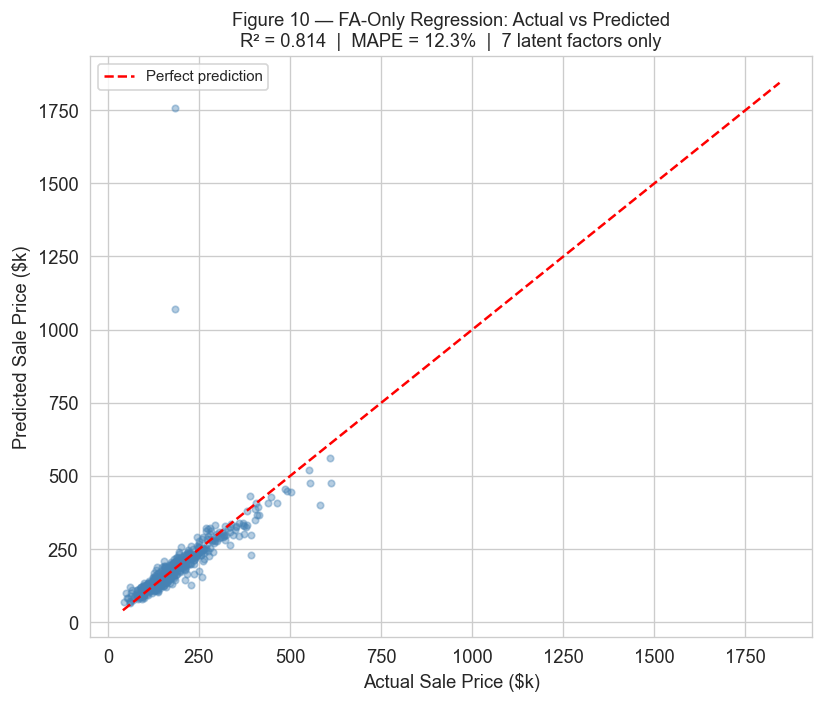

In [43]:
# Visualize actual vs predicted for the FA-only model
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test_fa_usd / 1000, y_pred_fa_usd / 1000,
           alpha=0.4, s=15, color='steelblue', rasterized=True)
lo = min(y_test_fa_usd.min(), y_pred_fa_usd.min()) / 1000 * 0.93
hi = max(y_test_fa_usd.max(), y_pred_fa_usd.max()) / 1000 * 1.05
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Sale Price ($k)')
ax.set_ylabel('Predicted Sale Price ($k)')
ax.set_title(f'Figure 10 — FA-Only Regression: Actual vs Predicted\n'
             f'R² = {r2_fa:.3f}  |  MAPE = {mape_fa:.1f}%  |  7 latent factors only',
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Analysis_Figs/fig10_fa_only_predictions.pdf', bbox_inches='tight')
plt.show()

The numbers tell a clear and surprisingly favorable story for the factor analysis result.

**The 7-factor model achieves R² = 0.81 — capturing about 92% of the predictive signal of the full model.** The full Ridge regression, with access to 224 features (all 56 numerical/ordinal variables plus all categorical dummies), reached R² = 0.88. Going from 224 features down to just 7 interpretable factor scores cost only 7 percentage points of R². This is a strong validation of the FA result: if the 7 factors were arbitrary mathematical constructs, this regression would perform far worse. Instead, the fact that "Quality/Newness + Vertical Size + Footprint + Garage + Basement Finish + Pool + Basement Condition" captures most of price variance tells us these constructs are real and predictively meaningful.

Furthermore, considering MAPE, FA-only model produces predictions that are off by 12.3% on average; the full Ridge model is off by 9.2%. That's a 3-percentage-point gap on the most intuitive error metric, achieved at the cost of using 224 features instead of 7.

Hwever note that the dollar RMSE is actually meaningfully larger and this is because dollar-scale RMSE is dominated by errors on high-priced homes, where the FA-only model lacks the granularity to capture luxury premiums like neighborhood-specific premiums that FA cannot access since it misses categorical variables.

In particular, FA cannot use:

1. **Categorical variables**, especially `Neighborhood`. We would expect that most of the 7-point gap is almost certainly here.
2. **Idiosyncratic numerical features**, i.e.the ~20 features FA flagged with h² < 0.3 like porches, fences, `Yr_Sold`, `Misc_Val`, `Low_Qual_Fin_SF`. Most likely they will carry small but real predictive signal that Ridge and Lasso can use individually.

Notheless, the benefit is that the 7-factor model is dramatically more communicable. "This house's price is determined by its size, quality, age, garage, basement finish, pool, and basement condition" is far more interpretable. The full Ridge model's prediction is built from 224 standardized coefficients including 24 neighborhood dummies. 

For automated valuation where pure predictive accuracy matters most, the full model wins. For contexts where the price has to be *explained* and justified like in more practical and business context, the 7-factor model with interpretable constructs offers a substantially clearer narrative at the cost of about 3 percentage points of MAPE. Different applications will weigh this tradeoff differently.
